In [ ]:
# ── dependencies ─────────────────────────────────────────────────────────────
import subprocess, sys

packages = ["hmmlearn", "statsmodels", "scipy", "pandas", "numpy", "matplotlib"]
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])


In [1]:
import os
import warnings
from datetime import datetime
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cm as cm
import statsmodels.api as sm
from scipy import stats
from scipy.optimize import minimize
from scipy.stats import linregress
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from hmmlearn.hmm import GaussianHMM
from IPython.display import display, Markdown
import hcl_functions3 as hcl

warnings.filterwarnings("ignore")
pd.options.display.float_format = "{:,.4f}".format


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# FUNCTION LIBRARY
# All helper and analysis functions are defined here.
# ══════════════════════════════════════════════════════════════════════════════
# =============================================================================
# SECTION 1: TIMESTAMP PARSING
# =============================================================================

_TIMESTAMP_FORMATS = [
    "%Y-%m-%d %H:%M:%S.%f",
    "%Y-%m-%d %H:%M:%S",
    "%Y-%m-%dT%H:%M:%S.%f",
    "%Y-%m-%dT%H:%M:%S",
    "%Y-%m-%d",
    "%d.%m.%Y %H:%M:%S",
    "%d.%m.%Y %H:%M",
    "%d.%m.%Y",
    "%d/%m/%Y %H:%M",
    "%m/%d/%Y %H:%M",
]


def parse_timestamp(ts) -> pd.Timestamp:
    """Parse a timestamp string in any of the supported formats."""
    if pd.isna(ts):
        return pd.NaT
    ts_str = str(ts).strip()
    for fmt in _TIMESTAMP_FORMATS:
        try:
            return pd.Timestamp(datetime.strptime(ts_str, fmt))
        except ValueError:
            continue
    try:
        return pd.to_datetime(ts_str)
    except Exception:
        return pd.NaT


def preprocess_btc_data_timestamps(
    btc_data: pd.DataFrame,
    timestamp_column: str = "retrieved_at_utc",
    verbose: bool = True,
) -> Tuple[pd.DataFrame, Dict]:
    """Parse btc_data timestamps and return a quality report."""
    df    = btc_data.copy()
    total = len(df)

    parsed       = df[timestamp_column].apply(parse_timestamp)
    failed_mask  = parsed.isna() & df[timestamp_column].notna()
    failed_indices = list(df.index[failed_mask][:10])

    df[timestamp_column] = parsed
    n_ok   = int(parsed.notna().sum())
    n_fail = int(failed_mask.sum())

    report = {
        "total_rows":          total,
        "successfully_parsed": n_ok,
        "failed_to_parse":     n_fail,
        "original_na_count":   int(btc_data[timestamp_column].isna().sum()),
        "parse_success_rate":  n_ok / total if total else 0.0,
        "failed_indices":      failed_indices,
        "timestamp_range_min": parsed.min(),
        "timestamp_range_max": parsed.max(),
    }

    if verbose:
        print("\nTIMESTAMP PREPROCESSING")
        print(f"  Total rows         : {total}")
        print(f"  Successfully parsed: {n_ok}  ({report['parse_success_rate']:.2%})")
        print(f"  Failed to parse    : {n_fail}")
        print(f"  Timestamp range    : {report['timestamp_range_min']}  ->  {report['timestamp_range_max']}")
        if n_fail:
            print(f"  First failed indices: {failed_indices}")
            print(f"  Tip: df.dropna(subset=['{timestamp_column}']) to remove unparseable rows")

    return df, report


# =============================================================================
# SECTION 2: FILENAME KEY EXTRACTION & BTC_DATA MATCHING
# =============================================================================

def extract_key_from_filename(filename: str) -> str:
    """
    Extract the contract-address key from a CSV filename.
    'agora_dollar_bitcoin_on_katana_katana_0x0c909f.csv'  ->  '0x0c909f'
    """
    return filename.replace(".csv", "").split("_")[-1]


def match_and_aggregate_btc_data(
    filename: str, btc_data: pd.DataFrame
) -> Tuple[Optional[Dict], str]:
    """
    Match a CSV file to btc_data rows via substring key match and aggregate
    all matching snapshots. Returns (aggregated_dict, key).
    """
    key     = extract_key_from_filename(filename)
    matches = btc_data[btc_data["unique_key"].str.contains(key, na=False, regex=False)]

    if matches.empty:
        return None, key

    def _mean(col):
        return matches[col].mean() if col in matches.columns else np.nan

    def _first(col):
        return matches[col].iloc[0] if col in matches.columns else np.nan

    aggregated = {
        "size_usd":                _mean("size_usd"),
        "size_usd_min":            matches["size_usd"].min() if "size_usd" in matches.columns else np.nan,
        "size_usd_max":            matches["size_usd"].max() if "size_usd" in matches.columns else np.nan,
        "size_usd_std":            matches["size_usd"].std() if "size_usd" in matches.columns else np.nan,
        "total_liquidity_usd":     _mean("total_liquidity_usd"),
        "current_borrow_usd":      _mean("current_borrow_usd"),
        "current_supply_usd":      _mean("current_supply_usd"),
        "borrow_apy":              _mean("borrow_apy"),
        "weekly_borrow_apy":       _mean("weekly_borrow_apy"),
        "monthly_borrow_apy":      _mean("monthly_borrow_apy"),
        "target_utilization":      _mean("target_utilization"),
        "lltv":                    _mean("lltv"),
        "collateral_asset_symbol": _first("collateral_asset_symbol"),
        "loan_asset_symbol":       _first("loan_asset_symbol"),
        "network":                 _first("network"),
        "source":                  _first("source"),
        "snapshot_count":          len(matches),
        "snapshot_start":          matches["retrieved_at_utc"].min() if "retrieved_at_utc" in matches.columns else pd.NaT,
        "snapshot_end":            matches["retrieved_at_utc"].max() if "retrieved_at_utc" in matches.columns else pd.NaT,
    }

    return aggregated, key


# =============================================================================
# SECTION 3: CSV LOADING & VALIDATION
# =============================================================================

def read_and_validate_market(filepath: str) -> Tuple[Optional[pd.DataFrame], Optional[str]]:
    """
    Load a market CSV and verify it contains exactly one trading pair.
    Returns (df, None) on success or (None, error_message) on failure.
    """
    try:
        df = pd.read_csv(filepath)
    except Exception as e:
        return None, f"Read error: {e}"

    if df.empty:
        return None, "Empty file"

    required_cols = {"date", "market", "collateral_asset_name", "loan_asset_name", "borrow_apy", "utilization"}
    missing = required_cols - set(df.columns)
    if missing:
        return None, f"Missing columns: {missing}"

    try:
        df["date"] = pd.to_datetime(df["date"])
    except Exception as e:
        return None, f"Date parse error: {e}"

    for col, label in [
        ("market",                "markets"),
        ("collateral_asset_name", "collateral assets"),
        ("loan_asset_name",       "loan assets"),
    ]:
        if df[col].nunique() > 1:
            return None, f"Multiple {label} in one file: {df[col].unique().tolist()}"

    return df, None


def load_filtered_markets_to_dict(
    csv_folder: str = "example/output",
    filter_keys: list = None,
) -> dict:
    """
    Load only specified markets into a dictionary keyed by unique contract address.

    Parameters
    ----------
    csv_folder  : path to folder containing CSV files
    filter_keys : list of unique keys to load; if None, loads all

    Returns
    -------
    dict  {unique_key: pd.DataFrame}
    """
    markets_dict = {}

    for fname in os.listdir(csv_folder):
        if not fname.endswith(".csv"):
            continue

        unique_key = fname.replace(".csv", "").split("_")[-1]

        if filter_keys is not None and unique_key not in filter_keys:
            continue

        filepath = os.path.join(csv_folder, fname)
        df       = pd.read_csv(filepath)
        df["date"] = pd.to_datetime(df["date"])
        df.set_index("date", inplace=True, drop=True)
        markets_dict[unique_key] = df

    return markets_dict


# =============================================================================
# SECTION 4: DATA FREQUENCY DETECTION
# =============================================================================

def detect_data_frequency(dates: pd.Series) -> Tuple[float, float]:
    """
    Infer data cadence from a datetime series.
    Returns (frequency_days, annualisation_factor).
    """
    if len(dates) < 2:
        return 1.0, np.sqrt(365)

    avg_hours = dates.diff().dropna().mean().total_seconds() / 3600

    if avg_hours <= 1:
        return 1 / 24, np.sqrt(365 * 24)
    elif avg_hours <= 24:
        return avg_hours / 24, np.sqrt(365 * 24 / avg_hours)
    elif avg_hours <= 168:
        return 7.0, np.sqrt(52)
    else:
        return 30.0, np.sqrt(12)


# =============================================================================
# SECTION 5: COMBINED SUMMARY CALCULATION
# =============================================================================

def calculate_combined_summary(
    csv_df: pd.DataFrame,
    btc_agg: Optional[Dict],
    filepath: str,
) -> Dict:
    """Merge CSV time-series metrics with btc_data snapshot aggregates."""
    freq_days, ann_factor = detect_data_frequency(csv_df["date"])
    latest   = csv_df.loc[csv_df["date"].idxmax()]
    earliest = csv_df.loc[csv_df["date"].idxmin()]

    def _g(key, default=np.nan):
        return btc_agg.get(key, default) if btc_agg else default

    snap_start = _g("snapshot_start", pd.NaT)
    snap_end   = _g("snapshot_end",   pd.NaT)
    snap_days  = (snap_end - snap_start).days if pd.notna(snap_start) and pd.notna(snap_end) else np.nan

    return {
        # Identity
        "file":                  os.path.basename(filepath),
        "unique_key":            extract_key_from_filename(os.path.basename(filepath)),
        "matched_to_btc_data":   btc_agg is not None,
        "btc_snapshot_count":    _g("snapshot_count", 0),
        "market":                csv_df["market"].iloc[0],
        "collateral_asset_csv":  csv_df["collateral_asset_name"].iloc[0],
        "loan_asset_csv":        csv_df["loan_asset_name"].iloc[0],
        "collateral_asset_btc":  _g("collateral_asset_symbol"),
        "loan_asset_btc":        _g("loan_asset_symbol"),
        "network":               _g("network"),
        "source":                _g("source"),
        # CSV history
        "csv_history_start":     earliest["date"],
        "csv_history_end":       latest["date"],
        "csv_history_days":      (latest["date"] - earliest["date"]).days,
        "csv_data_points":       len(csv_df),
        "data_frequency_days":   round(freq_days, 3),
        # Snapshot history
        "snapshot_history_start": snap_start,
        "snapshot_history_end":   snap_end,
        "snapshot_history_days":  snap_days,
        # APY (CSV)
        "avg_borrow_apy_csv":        csv_df["borrow_apy"].mean(),
        "median_borrow_apy_csv":     csv_df["borrow_apy"].median(),
        "min_borrow_apy_csv":        csv_df["borrow_apy"].min(),
        "max_borrow_apy_csv":        csv_df["borrow_apy"].max(),
        "current_borrow_apy_csv":    latest["borrow_apy"],
        "avg_borrow_apy_btc":        _g("borrow_apy"),
        "apy_volatility_annualized": csv_df["borrow_apy"].std() * ann_factor,
        # Utilization (CSV)
        "avg_utilization":             csv_df["utilization"].mean(),
        "median_utilization":          csv_df["utilization"].median(),
        "current_utilization_csv":     latest["utilization"],
        "util_volatility_annualized":  csv_df["utilization"].std() * ann_factor,
        # Market size (btc_data)
        "avg_size_usd":            _g("size_usd"),
        "min_size_usd":            _g("size_usd_min"),
        "max_size_usd":            _g("size_usd_max"),
        "size_volatility_usd":     _g("size_usd_std"),
        "avg_total_liquidity_usd": _g("total_liquidity_usd"),
        "avg_current_borrow_usd":  _g("current_borrow_usd"),
        "avg_current_supply_usd":  _g("current_supply_usd"),
        # Protocol parameters
        "avg_lltv":                   _g("lltv"),
        "avg_target_utilization_csv": csv_df["target_utilization"].mean() if "target_utilization" in csv_df.columns else np.nan,
        "borrow_rate_at_target":      latest.get("borrow_rate_at_target_utilization", np.nan),
    }


# =============================================================================
# SECTION 6: MAIN PROCESSING FUNCTION
# =============================================================================

def process_btc_markets_with_snapshot(
    folder_path: str,
    btc_data: pd.DataFrame,
) -> Tuple[pd.DataFrame, List[Dict], List[Dict]]:
    """
    Load all CSVs in folder_path, match to btc_data, filter to BTC-collateral
    markets, and return combined summaries.

    Returns (summary_df, errors, unmatched).
    """
    summaries, errors, unmatched = [], [], []

    csv_files = sorted(f for f in os.listdir(folder_path) if f.endswith(".csv"))
    print(f"\nProcessing {len(csv_files)} CSV files ...")

    for filename in csv_files:
        filepath = os.path.join(folder_path, filename)

        csv_df, err = read_and_validate_market(filepath)
        if err:
            errors.append({"file": filename, "error": err, "stage": "csv_load"})
            continue

        btc_agg, key = match_and_aggregate_btc_data(filename, btc_data)
        if btc_agg is None:
            unmatched.append({"file": filename, "key": key})
            continue

        if "BTC" not in str(btc_agg.get("collateral_asset_symbol", "")).upper():
            continue

        summaries.append(calculate_combined_summary(csv_df, btc_agg, filepath))

    result_df = pd.DataFrame(summaries)
    if not result_df.empty:
        result_df = result_df.sort_values("csv_history_days", ascending=False).reset_index(drop=True)

    print(f"  BTC markets processed : {len(result_df)}")
    print(f"  Unmatched files       : {len(unmatched)}")
    print(f"  Errors                : {len(errors)}")

    return result_df, errors, unmatched


# =============================================================================
# SECTION 7: STATISTICAL ANALYSIS
# =============================================================================

def stationarity_tests(series: pd.Series) -> Dict:
    """Run ADF and KPSS tests. Returns dict of key statistics."""
    series = series.dropna()

    adf_result  = adfuller(series)
    kpss_result = kpss(series, regression="c", nlags="auto")

    return {
        "ADF Statistic": adf_result[0],
        "ADF p-value":   adf_result[1],
        "ADF lags":      adf_result[2],
        "ADF nobs":      adf_result[3],
        "KPSS Statistic": kpss_result[0],
        "KPSS p-value":   kpss_result[1],
        "KPSS lags":      kpss_result[2],
    }


def _build_index(n_lags: int) -> List[str]:
    return (
        ["mean", "variance", "skewness", "excess_kurtosis"]
        + ["adf_stat", "adf_pval", "adf_lags_used", "adf_crit_5pct", "adf_reject_H0"]
        + ["kpss_stat", "kpss_pval", "kpss_lags_used", "kpss_crit_5pct", "kpss_reject_H0"]
        + ["stationary", "ci_band_95"]
        + [f"acf_lag_{l}"  for l in range(1, n_lags + 1)]
        + [f"pacf_lag_{l}" for l in range(1, n_lags + 1)]
    )


def analyze_borrow_rate_stats(
    df: pd.DataFrame,
    rate_col: str = "borrow_apy",
    date_col: str = "date",
    n_lags:   int = 10,
) -> pd.DataFrame:
    """
    Compute moments, stationarity tests, and ACF/PACF for both
    levels and first differences of a borrow rate series.
    Returns a DataFrame with columns [rate_col, rate_col_diff].
    """
    df = df.copy()
    if date_col in df.columns:
        df = df.sort_values(date_col)
    else:
        df = df.sort_index()

    series = df[rate_col].dropna()
    diff   = series.diff().dropna()
    index  = _build_index(n_lags)
    results = {}

    for s, col_label in [(series, rate_col), (diff, f"{rate_col}_diff")]:
        row = {k: np.nan for k in index}
        try:
            arr = s.to_numpy(dtype=float)
            n   = len(arr)
            row["ci_band_95"] = float(1.96 / np.sqrt(n))

            row["mean"]            = float(arr.mean())
            row["variance"]        = float(arr.var(ddof=1))
            row["skewness"]        = float(stats.skew(arr))
            row["excess_kurtosis"] = float(stats.kurtosis(arr, fisher=True))

            adf = adfuller(arr, autolag="AIC", regression="c")
            row["adf_stat"]      = float(adf[0])
            row["adf_pval"]      = float(adf[1])
            row["adf_lags_used"] = int(adf[2])
            row["adf_crit_5pct"] = float(adf[4]["5%"])
            row["adf_reject_H0"] = int(adf[1] < 0.05)

            kp = kpss(arr, regression="c", nlags="auto")
            row["kpss_stat"]      = float(kp[0])
            row["kpss_pval"]      = float(kp[1])
            row["kpss_lags_used"] = int(kp[2])
            crit = kp[3]
            row["kpss_crit_5pct"] = float(crit["5%"]) if isinstance(crit, dict) else float(crit)
            row["kpss_reject_H0"] = int(kp[1] < 0.05)

            adf_ok  = row["adf_reject_H0"]  == 1
            kpss_ok = row["kpss_reject_H0"] == 0
            if adf_ok and kpss_ok:
                row["stationary"] = 1
            elif not adf_ok and not kpss_ok:
                row["stationary"] = 0
            else:
                row["stationary"] = -1

            acf_raw  = acf(arr,  nlags=n_lags, fft=True)
            pacf_raw = pacf(arr, nlags=n_lags)
            acf_vals  = np.atleast_1d(acf_raw[0]  if isinstance(acf_raw,  tuple) else acf_raw)
            pacf_vals = np.atleast_1d(pacf_raw[0] if isinstance(pacf_raw, tuple) else pacf_raw)
            for lag in range(1, n_lags + 1):
                row[f"acf_lag_{lag}"]  = float(acf_vals[lag])
                row[f"pacf_lag_{lag}"] = float(pacf_vals[lag])

        except Exception:
            pass

        results[col_label] = row

    return pd.DataFrame(results)


def analyze_all_markets(
    filtered_markets: dict,
    rate_col: str = "borrow_apy",
    min_obs:  int = 100,
) -> pd.DataFrame:
    """
    Run analyze_borrow_rate_stats for all markets, separately for
    above and below target utilization subsets.

    Returns long-format DataFrame with columns: market, regime, + stat columns.
    """
    rows = []

    for market_id, df in filtered_markets.items():
        df = df.copy()
        if len(df) < min_obs:
            continue

        target = df["target_utilization"].iloc[0] if "target_utilization" in df.columns else None

        subsets = {"full": df}
        if target is not None:
            subsets["above_target"] = df[df["utilization"] >= target]
            subsets["below_target"] = df[df["utilization"] <  target]

        for regime_label, subset in subsets.items():
            if len(subset) < min_obs // 2:
                continue
            try:
                stats_df = analyze_borrow_rate_stats(subset.reset_index(), rate_col=rate_col)
                row      = stats_df[rate_col].to_dict()
                row["market"] = market_id
                row["regime"] = regime_label
                rows.append(row)
            except Exception:
                pass

    return pd.DataFrame(rows).set_index(["market", "regime"])


def stationarity_by_regime(
    series: pd.Series,
    states: np.ndarray,
    min_length: int = 30,
) -> None:
    """
    Test stationarity on contiguous regime episodes (not masked subsets).
    Prints ADF and KPSS p-values per episode.
    """
    series = series.dropna().copy()
    states = np.asarray(states)
    n      = min(len(series), len(states))
    series = series.iloc[:n]

    for regime in np.unique(states):
        episodes, in_ep = [], False
        for i, s in enumerate(states):
            if s == regime and not in_ep:
                start, in_ep = i, True
            elif s != regime and in_ep:
                episodes.append((start, i))
                in_ep = False
        if in_ep:
            episodes.append((start, len(states)))

        long_ep = [(s, e) for s, e in episodes if e - s >= min_length]
        print(f"\nRegime {regime}: {len(episodes)} episodes, {len(long_ep)} with n>={min_length}")

        for s, e in long_ep:
            episode = series.iloc[s:e]
            res     = stationarity_tests(episode)
            print(f"  [{series.index[s].date()} to {series.index[e-1].date()}] "
                  f"n={e-s} | ADF p={res['ADF p-value']:.4f} "
                  f"KPSS p={res['KPSS p-value']:.4f}")


# =============================================================================
# SECTION 8: REGIME DETECTION (HMM)
# =============================================================================

def fit_hmm_regimes(
    series:   pd.Series,
    n_states: int  = 2,
    plot:     bool = True,
) -> Tuple[np.ndarray, GaussianHMM]:
    """
    Fit a Gaussian HMM and return hard-assigned regime labels
    ordered by mean level (0 = lowest mean).
    """
    series = series.dropna()
    data   = series.values.reshape(-1, 1)

    model = GaussianHMM(
        n_components=n_states,
        covariance_type="full",
        n_iter=1000,
        random_state=42,
    )
    model.fit(data)
    states = model.predict(data)

    means = np.array([data[states == i].mean() for i in range(n_states)])
    order = np.argsort(means)

    remapped = np.zeros_like(states)
    for new, old in enumerate(order):
        remapped[states == old] = new

    if plot:
        plot_regimes(series, remapped)

    return remapped, model


def plot_regimes(
    series: pd.Series,
    states: np.ndarray,
    title:  str = "Regime Detection",
) -> None:
    """Plot time series with shaded regime backgrounds."""
    series = series.dropna()
    states = np.asarray(states)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(series.index, series.values, color="black", lw=1.5)

    colors  = ["steelblue", "darkorange", "green", "red"]
    ymin, ymax = float(series.min()), float(series.max())

    for regime in np.unique(states):
        mask = (states == regime).astype(bool)
        ax.fill_between(
            series.index, ymin, ymax,
            where=mask,
            alpha=0.25,
            color=colors[regime % len(colors)],
            label=f"Regime {regime}",
        )

    ax.set_title(title)
    ax.set_ylabel(series.name)
    ax.set_xlabel("Date")
    ax.legend()
    plt.tight_layout()
    plt.show()


# =============================================================================
# SECTION 9: ACF / PACF PLOTS
# =============================================================================

def plot_acf_pacf(
    series: pd.Series,
    lags:   int  = 40,
    title:  str  = None,
) -> None:
    """Plot ACF and PACF side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    plot_acf( series.dropna(), ax=axes[0], lags=lags)
    plot_pacf(series.dropna(), ax=axes[1], lags=lags, method="ywm")

    axes[0].set_title("ACF")
    axes[1].set_title("PACF")

    if title:
        fig.suptitle(title)

    plt.tight_layout()
    plt.show()


def plot_acf_pacf_by_regime(
    series: pd.Series,
    states: np.ndarray,
    lags:   int = 20,
) -> None:
    """
    Plot ACF and PACF separately for each regime.
    Uses boolean mask on the series — observations need not be contiguous.
    """
    series    = series.dropna().copy()
    states    = np.asarray(states)
    n         = min(len(series), len(states))
    aligned   = series.iloc[:n]
    n_regimes = len(np.unique(states))

    fig, axes = plt.subplots(n_regimes, 2, figsize=(12, 4 * n_regimes))

    for regime in np.unique(states):
        mask        = states == regime
        regime_data = aligned[mask]
        n_obs       = int(mask.sum())
        actual_lags = min(lags, n_obs // 2 - 1)

        print(f"Regime {regime}: n={n_obs}, mean={regime_data.mean():.4f}, std={regime_data.std():.4f}")

        plot_acf( regime_data, ax=axes[regime, 0], lags=actual_lags)
        plot_pacf(regime_data, ax=axes[regime, 1], lags=actual_lags, method="ywm")

        axes[regime, 0].set_title(f"Regime {regime} ACF  (n={n_obs}, mean={regime_data.mean():.3f})")
        axes[regime, 1].set_title(f"Regime {regime} PACF (n={n_obs}, std={regime_data.std():.3f})")

    plt.tight_layout()
    plt.show()


# =============================================================================
# SECTION 10: BORROW RATE DIAGNOSTICS PLOT
# =============================================================================

def plot_borrow_rate_diagnostics(
    df:       pd.DataFrame,
    rate_col: str = "borrow_apy",
    date_col: str = "date",
    n_lags:   int = 20,
    title:    str = None,
) -> plt.Figure:
    """2×2 diagnostic plot: ACF, PACF, level distribution, returns distribution."""
    df = df.copy()
    if date_col in df.columns:
        df = df.sort_values(date_col)
    else:
        df = df.sort_index()

    levels  = df[rate_col].dropna().to_numpy(dtype=float)
    returns = np.diff(levels)
    n       = len(returns)
    ci      = 1.96 / np.sqrt(n)

    acf_raw  = acf(returns,  nlags=n_lags, fft=True)
    pacf_raw = pacf(returns, nlags=n_lags)
    acf_vals  = np.atleast_1d(acf_raw[0]  if isinstance(acf_raw,  tuple) else acf_raw)
    pacf_vals = np.atleast_1d(pacf_raw[0] if isinstance(pacf_raw, tuple) else pacf_raw)
    lags      = np.arange(0, n_lags + 1)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    (ax_acf, ax_dist_levels), (ax_pacf, ax_dist_returns) = axes

    for ax, vals, label in [
        (ax_acf,  acf_vals,  "ACF — returns"),
        (ax_pacf, pacf_vals, "PACF — returns"),
    ]:
        ax.vlines(lags[1:], 0, vals[1:], colors="steelblue", linewidth=1.5)
        ax.scatter(lags[1:], vals[1:], color="steelblue", s=20, zorder=3)
        ax.axhline(0,   color="black", linewidth=0.8)
        ax.axhline( ci, color="red", linestyle="--", linewidth=0.9, label="95% CI")
        ax.axhline(-ci, color="red", linestyle="--", linewidth=0.9)
        ax.set_title(label)
        ax.set_xlabel("Lag")
        ax.set_xlim(0, n_lags + 1)
        ax.legend(fontsize=8)

    ax_acf.set_ylabel("Autocorrelation")
    ax_pacf.set_ylabel("Partial autocorrelation")

    for ax, data, col_label in [
        (ax_dist_levels,  levels,  rate_col),
        (ax_dist_returns, returns, f"Δ{rate_col}"),
    ]:
        ax.hist(data, bins=200, color="steelblue", edgecolor="white", linewidth=0.3)
        ax.axvline(np.mean(data),   color="red",    linestyle="--", linewidth=1,
                   label=f"mean={np.mean(data):.4f}")
        ax.axvline(np.median(data), color="orange", linestyle="--", linewidth=1,
                   label=f"median={np.median(data):.4f}")
        ax.set_title(f"Distribution — {col_label}")
        ax.set_xlabel(col_label)
        ax.set_ylabel("Count")
        ax.legend(fontsize=8)

    if title is None:
        market = df["market"].iloc[0] if "market" in df.columns else rate_col
        title  = f"{market} — borrow rate diagnostics"
    fig.suptitle(title, fontsize=13, fontweight="bold")
    fig.tight_layout()
    return fig


# =============================================================================
# SECTION 11: VISUALISATION HELPERS
# =============================================================================

def plot_compact(
    keys:         list,
    markets_dict: dict,
    meta_df:      pd.DataFrame,
    metric:       str = "rolling_7d_apy",
) -> None:
    """
    Compact line plot for multiple markets.
    Legend format: 'market (network)'.
    Expects date as DataFrame index.
    """
    fig, ax     = plt.subplots(figsize=(12, 5))
    plotted     = 0

    for i, k in enumerate(keys):
        if k not in markets_dict:
            continue
        if k not in meta_df["unique_key"].values:
            continue

        df = markets_dict[k]
        if metric not in df.columns:
            continue

        m     = meta_df[meta_df["unique_key"] == k].iloc[0]
        label = f"{m['market']} ({m['network']})"

        mask = df[metric].notna()
        x, y = df.index[mask], df.loc[mask, metric]
        if len(x) == 0:
            continue

        ax.plot(x, y, label=label,
                color=plt.cm.tab10(plotted % 10), linewidth=1.5)
        plotted += 1

    if plotted == 0:
        plt.close(fig)
        return

    ax.set_xlabel("Date")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} — {plotted} markets")
    ax.legend(fontsize=8, loc="best", frameon=True)
    ax.grid(alpha=0.3)
    ax.ticklabel_format(style="plain", axis="y")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def plot_utilization_rate_scatter(
    df:    pd.DataFrame,
    x_col: str = "utilization",
    y_col: str = "normalized_apy",
    title: str = None,
) -> plt.Figure:
    """Scatter of y vs x coloured by date with OLS regression line."""
    dates     = df.index.to_numpy()
    date_nums = mdates.date2num(dates)

    x = df[x_col].to_numpy(dtype=float)
    y = df[y_col].to_numpy(dtype=float)

    slope, intercept, r, _, _ = linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = slope * x_line + intercept

    formula = (
        f"$\\hat{{y}} = {slope:.3f} \\cdot x "
        f"{'+ ' if intercept >= 0 else '- '}{abs(intercept):.3f}$"
        f"   $R^2 = {r**2:.3f}$"
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    sc  = ax.scatter(x, y, c=date_nums, cmap="viridis", s=10, alpha=0.7)
    ax.plot(x_line, y_line, color="red", linewidth=1.5, label=formula)

    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label("Date")
    cbar.ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda v, _: mdates.num2date(v).strftime("%Y-%m"))
    )

    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(title or f"{y_col} vs {x_col}")
    ax.legend(fontsize=10, loc="upper left")
    fig.tight_layout()
    return fig


# =============================================================================
# SECTION 12: OLS FIT
# =============================================================================

def fit_ols(
    df:    pd.DataFrame,
    x_col: str = "utilization",
    y_col: str = "normalized_apy",
) -> Dict:
    """
    Simple OLS fit of y on x.
    Returns dict: slope, intercept, r_squared, residuals (pd.Series).
    """
    x = df[x_col].to_numpy(dtype=float)
    y = df[y_col].to_numpy(dtype=float)

    slope, intercept, r, _, _ = linregress(x, y)
    fitted    = slope * x + intercept
    residuals = pd.Series(y - fitted, index=df.index)

    return {
        "slope":     slope,
        "intercept": intercept,
        "r_squared": r ** 2,
        "residuals": residuals,
    }


# =============================================================================
# SECTION 13: ADAPTIVE CURVE IRM
# =============================================================================

def irm_curve(
    rate_at_target:     float,
    utilization:        float,
    curve_steepness:    float = 4.0,
    target_utilization: float = 0.9,
) -> float:
    """
    Morpho AdaptiveCurveIRM analytical rate.
    Mirrors AdaptiveCurveIrm.sol _borrowRate() logic.
    """
    if utilization > target_utilization:
        err_norm = 1.0 - target_utilization
        err      = (utilization - target_utilization) / err_norm
        coeff    = curve_steepness - 1.0
    else:
        err_norm = target_utilization
        err      = (utilization - target_utilization) / err_norm
        coeff    = 1.0 - 1.0 / curve_steepness

    return (coeff * err + 1.0) * rate_at_target


def model_rate_impact(
    current_supply_usd:  float,
    current_utilization: float,
    current_borrow_apy:  float,
    rate_at_target:      float,
    add_borrow_usd:      "float | list[float]",
    curve_steepness:     float = 4.0,
    target_utilization:  float = 0.9,
) -> pd.DataFrame:
    """
    Compute new utilization and borrow rate for one or more
    incremental borrow amounts.
    Returns a DataFrame with one row per scenario.
    """
    scenarios = [add_borrow_usd] if isinstance(add_borrow_usd, (int, float)) else list(add_borrow_usd)

    current_borrow_usd      = current_supply_usd * current_utilization
    available               = current_supply_usd - current_borrow_usd
    current_rate_analytical = irm_curve(rate_at_target, current_utilization, curve_steepness, target_utilization)
    analytical_error_bps    = round((current_rate_analytical - current_borrow_apy) * 10_000, 2)

    rows = []
    for x in scenarios:
        if x > available:
            new_util, note = 1.0, "exceeds available liquidity"
        else:
            new_util, note = (current_borrow_usd + x) / current_supply_usd, ""

        new_rate = irm_curve(rate_at_target, new_util, curve_steepness, target_utilization)

        rows.append({
            "add_borrow_usd":          x,
            "current_util":            round(current_utilization, 6),
            "new_util":                round(new_util, 6),
            "current_rate_observed":   round(current_borrow_apy, 6),
            "current_rate_analytical": round(current_rate_analytical, 6),
            "analytical_error_bps":    analytical_error_bps,
            "new_rate":                round(new_rate, 6),
            "rate_delta":              round(new_rate - current_borrow_apy, 6),
            "rate_delta_bps":          round((new_rate - current_borrow_apy) * 10_000, 2),
            "available_liquidity_usd": round(available, 2),
            "note":                    note,
        })

    return pd.DataFrame(rows)


def market_state_from_timeseries(ts: pd.DataFrame) -> dict:
    """Extract current market state from a time-series DataFrame."""
    row  = ts.sort_values("date").iloc[-1]
    util = float(row["utilization"])
    rat  = float(row["borrow_rate_at_target_utilization"])

    analytical = irm_curve(rat, util, target_utilization=float(row["target_utilization"]))

    return {
        "current_utilization":     util,
        "current_borrow_apy":      float(row["borrow_apy"]),
        "rate_at_target":          rat,
        "target_utilization":      float(row["target_utilization"]),
        "current_rate_analytical": analytical,
        "analytical_error_bps":    round((analytical - float(row["borrow_apy"])) * 10_000, 2),
        "current_supply_usd":      None,
    }


def market_state_from_snapshot(snapshot: "pd.Series | pd.DataFrame") -> dict:
    """Extract current market state from a snapshot Series or single-row DataFrame."""
    if isinstance(snapshot, pd.DataFrame):
        snapshot = snapshot.iloc[0]

    supply = float(snapshot["current_supply_usd"])
    borrow = float(snapshot["current_borrow_usd"])

    return {
        "current_supply_usd":  supply,
        "current_utilization": borrow / supply,
        "current_borrow_apy":  float(snapshot["borrow_apy"]),
        "rate_at_target":      float(snapshot["borrow_rate_at_target_utilization"]),
        "target_utilization":  float(snapshot["target_utilization"]),
        "available_usd":       supply - borrow,
        "amount_to_target":    snapshot.get("amount_to_target_utilization", None),
    }


def run_impact_scenarios(
    market_snapshots: pd.DataFrame,
    unique_key:       str,
    add_borrow_usd:   "float | list[float]",
) -> pd.DataFrame:
    """Run model_rate_impact for a market identified by unique_key."""
    subset = market_snapshots[market_snapshots["unique_key"].str.contains(unique_key)]
    state  = market_state_from_snapshot(subset)

    return model_rate_impact(
        current_supply_usd  = state["current_supply_usd"],
        current_utilization = state["current_utilization"],
        current_borrow_apy  = state["current_borrow_apy"],
        rate_at_target      = state["rate_at_target"],
        add_borrow_usd      = add_borrow_usd,
        target_utilization  = state["target_utilization"],
    )


# =============================================================================
# SECTION 14: BORROW RATE FORECASTING
# =============================================================================

def prepare_series(market_df: pd.DataFrame) -> pd.Series:
    """
    Convert weekly_borrow_apy to log1p-scale daily series, multiplied by 100.

    Transform: s = log(1 + APY) × 100

    Why log1p: correct for rates expressed as decimals (0.05 = 5%).
    Why ×100:  log1p diffs are O(0.003–0.03) at typical APY levels — too small
               for EM covariance estimation (SVD failures). Scaling to percentage
               points gives diffs O(0.3–3), which is numerically stable.

    Inverse:   APY = exp(s / 100) - 1  i.e. np.expm1(s / 100)
    """
    return (
        (market_df["weekly_borrow_apy"] + 1)
        .apply(np.log)
        .multiply(100)
        .resample("D")
        .last()
        .dropna()
    )


def fit_forecast_model(series: pd.Series):
    """
    Fit Markov-switching AR(2) on differenced log series.
    Returns (res, diff, series).
    """
    series = series.dropna()
    diff   = series.diff().dropna()

    mod = sm.tsa.MarkovAutoregression(
        diff,
        k_regimes=2,
        order=2,
        switching_ar=False,
        switching_variance=True,
    )
    res = mod.fit(em_iter=100)
    print(res.summary())
    return res, diff, series


def fit_per_market_models(
    filtered_markets: dict,
) -> Tuple[Dict, Dict]:
    """
    Fit Markov-AR(2) independently per market.
    Returns (results_dict, series_dict).
    """
    results, series_dict = {}, {}

    for market_id, market_df in filtered_markets.items():
        s = prepare_series(market_df)
        if len(s) < 60:
            print(f"Skipping {market_id}: only {len(s)} obs")
            continue
        try:
            diff = s.diff().dropna()
            mod  = sm.tsa.MarkovAutoregression(
                diff, k_regimes=2, order=2,
                switching_ar=False, switching_variance=True,
            )
            res                    = mod.fit(em_iter=100)
            results[market_id]     = res
            series_dict[market_id] = s
            print(f"Fitted {market_id}: AIC={res.aic:.1f}")
        except Exception as e:
            print(f"Failed {market_id}: {e}")

    return results, series_dict


def extract_shared_params(results: Dict) -> Dict:
    """
    Compute median AR and transition params across all fitted markets.
    Median is used for robustness against degenerate single-market fits.
    """
    param_keys = ["ar.L1", "ar.L2", "p[0->0]", "p[1->0]"]
    collected  = {k: [] for k in param_keys}

    for market_id, res in results.items():
        try:
            for k in param_keys:
                collected[k].append(res.params[k])
        except Exception as e:
            print(f"Could not extract params from {market_id}: {e}")

    shared = {}
    for k, vals in collected.items():
        arr       = np.array(vals)
        shared[k] = np.median(arr)
        print(f"{k}: median={shared[k]:.4f}  min={arr.min():.4f}  max={arr.max():.4f}  n={len(arr)}")

    return shared


def simulate_paths(
    res,
    series:   pd.Series,
    horizon:  int = 30,
    n_sims:   int = 10_000,
) -> pd.DataFrame:
    """
    Monte Carlo forecast using a single fitted MarkovAutoregression result.
    Returns DataFrame in APY space (0.05 = 5%).
    """
    series = series.dropna()
    diff   = series.diff().dropna()

    ar1    = res.params["ar.L1"]
    ar2    = res.params["ar.L2"]
    sigma2 = [res.params["sigma2[0]"], res.params["sigma2[1]"]]

    P = np.array([
        [res.params["p[0->0]"],       1 - res.params["p[1->0]"]],
        [1 - res.params["p[0->0]"],   res.params["p[1->0]"]    ],
    ])

    last_regime = int(np.argmax(res.smoothed_marginal_probabilities.values[-1]))
    last_diff   = float(diff.values[-1])
    last_diff2  = float(diff.values[-2])
    last_level  = float(series.values[-1])

    rng   = np.random.default_rng(42)
    paths = np.zeros((n_sims, horizon))

    for sim in range(n_sims):
        regime, dp1, dp2, level = last_regime, last_diff, last_diff2, last_level
        for t in range(horizon):
            regime = rng.choice(2, p=P[:, regime])
            eps    = rng.normal(0, np.sqrt(sigma2[regime]))
            d_next = ar1 * dp1 + ar2 * dp2 + eps
            level  = level + d_next
            paths[sim, t] = level
            dp2, dp1 = dp1, d_next

    # inverse: APY = exp(s / 100) - 1
    paths_apy      = np.expm1(paths / 100)
    last_date      = series.index[-1]
    forecast_dates = pd.date_range(start=last_date, periods=horizon + 1, freq="D")[1:]

    return pd.DataFrame({
        "mean":  paths_apy.mean(axis=0),
        "ci_5":  np.percentile(paths_apy,  5, axis=0),
        "ci_25": np.percentile(paths_apy, 25, axis=0),
        "ci_75": np.percentile(paths_apy, 75, axis=0),
        "ci_95": np.percentile(paths_apy, 95, axis=0),
    }, index=forecast_dates)


def simulate_paths_shared(
    shared_params: Dict,
    series:        pd.Series,
    horizon:       int = 30,
    n_sims:        int = 10_000,
) -> pd.DataFrame:
    """
    Monte Carlo forecast using shared AR/transition params
    with market-specific variance estimated from recent history.
    Returns DataFrame in APY space (0.05 = 5%).
    """
    series = series.dropna()
    diff   = series.diff().dropna()

    ar1 = shared_params["ar.L1"]
    ar2 = shared_params["ar.L2"]

    P = np.array([
        [shared_params["p[0->0]"],       1 - shared_params["p[1->0]"]],
        [1 - shared_params["p[0->0]"],   shared_params["p[1->0]"]    ],
    ])

    # per-market variance from two halves of last 60 obs
    recent = diff.iloc[-60:]
    half   = len(recent) // 2
    sigma2 = [
        max(float(recent.iloc[:half].var()), 1e-6),
        max(float(recent.iloc[half:].var()),  1e-6),
    ]
    last_regime = int(np.argmin(sigma2))
    last_diff   = float(diff.values[-1])
    last_diff2  = float(diff.values[-2])
    last_level  = float(series.values[-1])

    rng   = np.random.default_rng(42)
    paths = np.zeros((n_sims, horizon))

    for sim in range(n_sims):
        regime, dp1, dp2, level = last_regime, last_diff, last_diff2, last_level
        for t in range(horizon):
            regime = rng.choice(2, p=P[:, regime])
            eps    = rng.normal(0, np.sqrt(sigma2[regime]))
            d_next = ar1 * dp1 + ar2 * dp2 + eps
            level  = level + d_next
            paths[sim, t] = level
            dp2, dp1 = dp1, d_next

    # inverse: APY = exp(s / 100) - 1
    paths_apy      = np.expm1(paths / 100)
    last_date      = series.index[-1]
    forecast_dates = pd.date_range(start=last_date, periods=horizon + 1, freq="D")[1:]

    return pd.DataFrame({
        "mean":  paths_apy.mean(axis=0),
        "ci_5":  np.percentile(paths_apy,  5, axis=0),
        "ci_25": np.percentile(paths_apy, 25, axis=0),
        "ci_75": np.percentile(paths_apy, 75, axis=0),
        "ci_95": np.percentile(paths_apy, 95, axis=0),
    }, index=forecast_dates)


def forecast_all_markets_shared(
    shared_params: Dict,
    series_dict:   Dict,
    horizon:       int = 30,
    n_sims:        int = 10_000,
) -> Dict:
    """Run simulate_paths_shared for every market in series_dict."""
    forecasts = {}
    for market_id, series in series_dict.items():
        try:
            forecasts[market_id] = simulate_paths_shared(
                shared_params, series, horizon=horizon, n_sims=n_sims
            )
            print(f"Forecasted {market_id}")
        except Exception as e:
            print(f"Failed {market_id}: {e}")
    return forecasts


def collect_forecast_table(forecasts: Dict) -> pd.DataFrame:
    """
    Collect all market forecasts into a single long-format table.
    Columns: market_id, date, mean, ci_5, ci_25, ci_75, ci_95 (APY decimal)
             + _pct variants (APY × 100, rounded to 2dp).
    """
    rows = []
    for market_id, forecast_df in forecasts.items():
        df              = forecast_df.copy()
        df.index.name   = "date"
        df              = df.reset_index()
        df.insert(0, "market_id", market_id)
        rows.append(df)

    table = pd.concat(rows, ignore_index=True)

    for col in ["mean", "ci_5", "ci_25", "ci_75", "ci_95"]:
        table[f"{col}_pct"] = (table[col] * 100).round(2)

    return table


def print_forecast_summary(table: pd.DataFrame) -> pd.DataFrame:
    """Print 30-day terminal forecast per market (mean + 90% CI)."""
    summary = (
        table.groupby("market_id")
             .last()
             .reset_index()
        [["market_id", "mean_pct", "ci_5_pct", "ci_95_pct"]]
    )
    summary.columns = ["market_id", "30d_mean_%", "5th_pct_%", "95th_pct_%"]
    print(summary.to_string(index=False))
    return summary


def plot_forecast(
    series:        pd.Series,
    forecast_df:   pd.DataFrame,
    lookback_days: int = 120,
) -> None:
    """Plot historical series + 30-day Monte Carlo forecast with CI bands."""
    series  = series.dropna()
    history = np.expm1(series.iloc[-lookback_days:] / 100)

    fig, ax = plt.subplots(figsize=(13, 5))

    ax.plot(history.index, history.values,
            color="steelblue", lw=1.5, label="Historical")

    ax.fill_between(forecast_df.index,
                    forecast_df["ci_5"], forecast_df["ci_95"],
                    alpha=0.15, color="steelblue", label="90% CI")
    ax.fill_between(forecast_df.index,
                    forecast_df["ci_25"], forecast_df["ci_75"],
                    alpha=0.30, color="steelblue", label="50% CI")

    ax.plot(forecast_df.index, forecast_df["mean"],
            color="white", lw=2, label="Forecast mean")

    ax.plot([history.index[-1], forecast_df.index[0]],
            [history.values[-1], forecast_df["mean"].iloc[0]],
            color="white", lw=1.5, linestyle="--")

    ax.axvline(history.index[-1], color="gray", linestyle="--", alpha=0.5)

    ax.set_title("30-Day Borrow Rate Forecast")
    ax.set_ylabel("Borrow APY")
    ax.set_xlabel("Date")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1%}"))
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_all_forecasts(
    series_dict:   Dict,
    forecasts:     Dict,
    lookback_days: int = 120,
) -> None:
    """Grid plot of historical + forecast for every market."""
    n     = len(forecasts)
    ncols = 2
    nrows = (n + 1) // 2

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
    axes      = axes.flatten()

    for idx, (market_id, forecast_df) in enumerate(forecasts.items()):
        ax      = axes[idx]
        series  = series_dict[market_id]
        history = np.expm1(series.iloc[-lookback_days:] / 100)

        ax.plot(history.index, history.values,
                color="steelblue", lw=1.5, label="Historical")
        ax.fill_between(forecast_df.index,
                        forecast_df["ci_5"], forecast_df["ci_95"],
                        alpha=0.15, color="steelblue", label="90% CI")
        ax.fill_between(forecast_df.index,
                        forecast_df["ci_25"], forecast_df["ci_75"],
                        alpha=0.30, color="steelblue", label="50% CI")
        ax.plot(forecast_df.index, forecast_df["mean"],
                color="white", lw=2, label="Forecast mean")
        ax.plot([history.index[-1], forecast_df.index[0]],
                [history.values[-1], forecast_df["mean"].iloc[0]],
                color="white", lw=1.5, linestyle="--")
        ax.axvline(history.index[-1], color="gray", linestyle="--", alpha=0.5)
        ax.set_title(market_id, fontsize=10)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1%}"))

    for idx in range(len(forecasts), len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle("30-Day Borrow Rate Forecasts — All Markets", y=1.01, fontsize=13)
    plt.tight_layout()
    plt.show()


# =============================================================================
# SECTION 15: PORTFOLIO OPTIMISATION
# =============================================================================

def build_market_state(
    forecasts:     Dict,
    series_dict:   Dict,
    btc_data_clean: pd.DataFrame,
) -> pd.DataFrame:
    """
    Build per-market state table needed for optimisation.
    Joins live snapshot data with 30-day forecast APY.

    Returns DataFrame indexed by market_id with columns:
        supply_usd, borrow_usd, available_usd, current_util,
        lltv, safe_ltv, rate_at_target, target_util, forecast_apy
    """
    rows = []
    for key, forecast_df in forecasts.items():
        if key not in series_dict:
            continue

        snap = btc_data_clean[btc_data_clean["unique_key"].str.contains(key)]
        if snap.empty:
            continue

        snap     = snap.sort_values("retrieved_at_utc").iloc[-1]
        supply   = float(snap["current_supply_usd"])
        borrow   = float(snap["current_borrow_usd"])
        lltv     = float(snap["lltv"])
        rat      = float(snap["borrow_rate_at_target_utilization"])
        target_u = float(snap["target_utilization"])

        available    = supply - borrow
        current_u    = borrow / supply if supply > 0 else np.nan
        forecast_apy = float(forecast_df["mean"].mean())

        rows.append({
            "market_id":      key,
            "supply_usd":     supply,
            "borrow_usd":     borrow,
            "available_usd":  available,
            "current_util":   current_u,
            "lltv":           lltv,
            "safe_ltv":       lltv * 0.75,
            "rate_at_target": rat,
            "target_util":    target_u,
            "forecast_apy":   forecast_apy,
        })

    return pd.DataFrame(rows).set_index("market_id")


def compute_market_rate_post_borrow(
    key:      str,
    add_borrow: float,
    mkt_row:  pd.Series,
) -> float:
    """
    Analytical borrow rate after adding `add_borrow` USD to market `key`.
    Uses IRM curve from Section 13.
    """
    supply   = mkt_row["supply_usd"]
    borrow   = mkt_row["borrow_usd"]
    rat      = mkt_row["rate_at_target"]
    target_u = mkt_row["target_util"]

    if supply <= 0:
        return float(mkt_row["forecast_apy"])

    new_util = min((borrow + add_borrow) / supply, 1.0)
    return irm_curve(rat, new_util, target_utilization=target_u)


def blended_cost_objective(
    x:       np.ndarray,
    mkt:     pd.DataFrame,
    ltv_arr: np.ndarray,
) -> float:
    """
    Total annualised borrowing cost in USD.

    x       : collateral allocation per market (length N)
    mkt     : market state DataFrame (indexed by market_id)
    ltv_arr : operating LTV per market

    Non-linear because rate depends on borrow amount (IRM curve).
    """
    total = 0.0
    for i, (key, row) in enumerate(mkt.iterrows()):
        borrow_amt = x[i] * ltv_arr[i]
        rate       = compute_market_rate_post_borrow(key, borrow_amt, row)
        total     += borrow_amt * rate
    return total


def solve_allocation(
    mkt:            pd.DataFrame,
    total_capital:  float = 10_000_000,
    min_allocation: float = 500_000,
    ltv_arr:        np.ndarray = None,
    n_restarts:     int = 1,
) -> Tuple[np.ndarray, float, bool]:
    """
    Solve the portfolio optimisation via SLSQP.

    Parameters
    ----------
    mkt            : market state DataFrame from build_market_state()
    total_capital  : total collateral in USD
    min_allocation : minimum per-market allocation (smaller positions zeroed out)
    ltv_arr        : per-market LTV; defaults to safe_ltv (75% of LLTV)
    n_restarts     : number of random restarts for stability check

    Returns
    -------
    (x_opt, objective_value, converged)
    """
    from scipy.optimize import minimize

    if ltv_arr is None:
        ltv_arr = mkt["safe_ltv"].values

    N     = len(mkt)
    upper = np.minimum(
        total_capital,
        mkt["available_usd"].values / np.where(ltv_arr > 0, ltv_arr, 1.0),
    )
    bounds      = [(0.0, float(u)) for u in upper]
    constraints = [{"type": "eq", "fun": lambda x: x.sum() - total_capital}]

    best_res = None
    rng      = np.random.default_rng(42)

    for trial in range(max(1, n_restarts)):
        if trial == 0:
            x0 = np.clip(np.full(N, total_capital / N), 0, upper)
        else:
            x0 = np.clip(rng.dirichlet(np.ones(N)) * total_capital, 0, upper)
        x0 = x0 / x0.sum() * total_capital

        res = minimize(
            blended_cost_objective, x0,
            args=(mkt, ltv_arr),
            method="SLSQP",
            bounds=bounds,
            constraints=constraints,
            options={"ftol": 1e-10, "maxiter": 1000},
        )

        if best_res is None or (res.success and res.fun < best_res.fun):
            best_res = res

    x_opt = best_res.x.copy()
    x_opt[x_opt < min_allocation] = 0.0
    if x_opt.sum() > 0:
        x_opt = x_opt / x_opt.sum() * total_capital

    return x_opt, best_res.fun, best_res.success


def build_allocation_table(
    x_opt:   np.ndarray,
    mkt:     pd.DataFrame,
    ltv_arr: np.ndarray = None,
) -> pd.DataFrame:
    """
    Build readable allocation table from optimised weights.
    Returns DataFrame with one row per active market.
    """
    if ltv_arr is None:
        ltv_arr = mkt["safe_ltv"].values

    alloc                   = mkt.copy()
    alloc["collateral_usd"] = x_opt
    alloc["borrow_usd_new"] = x_opt * ltv_arr
    alloc["weight_pct"]     = x_opt / x_opt.sum() * 100 if x_opt.sum() > 0 else 0.0

    alloc["rate_after"] = [
        compute_market_rate_post_borrow(
            key, alloc.loc[key, "borrow_usd_new"], alloc.loc[key]
        )
        for key in alloc.index
    ]

    alloc["annual_cost_usd"]  = alloc["borrow_usd_new"] * alloc["rate_after"]
    alloc["monthly_cost_usd"] = alloc["annual_cost_usd"] / 12

    return alloc[alloc["collateral_usd"] > 0].copy()


def sensitivity_analysis(
    mkt:            pd.DataFrame,
    total_capital:  float = 10_000_000,
    min_allocation: float = 500_000,
) -> pd.DataFrame:
    """
    Run optimisation under six scenarios and return comparison table.

    Scenarios:
      - Baseline
      - Rates +100bps / -100bps
      - Largest market liquidity -50%
      - AUM $5M / $20M
    """
    def _run(label, mkt_s, capital=total_capital):
        ltv = mkt_s["safe_ltv"].values
        x, obj, ok = solve_allocation(mkt_s, capital, min_allocation, ltv)
        borrow  = float((x * ltv).sum())
        apy     = obj / borrow if borrow > 0 else np.nan
        monthly = obj / 12
        return {
            "scenario":       label,
            "blended_apy":    round(apy * 100, 3),
            "monthly_cost":   round(monthly),
            "active_markets": int((x > 0).sum()),
            "converged":      ok,
        }

    rows = [_run("Baseline", mkt)]

    m = mkt.copy(); m["rate_at_target"] = m["rate_at_target"] + 0.01
    rows.append(_run("Rates +100bps", m))

    m = mkt.copy(); m["rate_at_target"] = (m["rate_at_target"] - 0.01).clip(lower=0.001)
    rows.append(_run("Rates -100bps", m))

    top = mkt["available_usd"].idxmax()
    m   = mkt.copy(); m.loc[top, "available_usd"] *= 0.5
    rows.append(_run(f"Liquidity -50% ({top})", m))

    rows.append(_run("AUM $5M",  mkt, capital=5_000_000))
    rows.append(_run("AUM $20M", mkt, capital=20_000_000))

    return pd.DataFrame(rows)

import os
import warnings
from datetime import datetime
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cm as cm
import statsmodels.api as sm
from scipy import stats
from scipy.stats import linregress
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from hmmlearn.hmm import GaussianHMM

warnings.filterwarnings("ignore")


# =============================================================================
# SECTION 1: TIMESTAMP PARSING
# =============================================================================

_TIMESTAMP_FORMATS = [
    "%Y-%m-%d %H:%M:%S.%f",
    "%Y-%m-%d %H:%M:%S",
    "%Y-%m-%dT%H:%M:%S.%f",
    "%Y-%m-%dT%H:%M:%S",
    "%Y-%m-%d",
    "%d.%m.%Y %H:%M:%S",
    "%d.%m.%Y %H:%M",
    "%d.%m.%Y",
    "%d/%m/%Y %H:%M",
    "%m/%d/%Y %H:%M",
]


def parse_timestamp(ts) -> pd.Timestamp:
    """Parse a timestamp string in any of the supported formats."""
    if pd.isna(ts):
        return pd.NaT
    ts_str = str(ts).strip()
    for fmt in _TIMESTAMP_FORMATS:
        try:
            return pd.Timestamp(datetime.strptime(ts_str, fmt))
        except ValueError:
            continue
    try:
        return pd.to_datetime(ts_str)
    except Exception:
        return pd.NaT


def preprocess_btc_data_timestamps(
    btc_data: pd.DataFrame,
    timestamp_column: str = "retrieved_at_utc",
    verbose: bool = True,
) -> Tuple[pd.DataFrame, Dict]:
    """Parse btc_data timestamps and return a quality report."""
    df    = btc_data.copy()
    total = len(df)

    parsed       = df[timestamp_column].apply(parse_timestamp)
    failed_mask  = parsed.isna() & df[timestamp_column].notna()
    failed_indices = list(df.index[failed_mask][:10])

    df[timestamp_column] = parsed
    n_ok   = int(parsed.notna().sum())
    n_fail = int(failed_mask.sum())

    report = {
        "total_rows":          total,
        "successfully_parsed": n_ok,
        "failed_to_parse":     n_fail,
        "original_na_count":   int(btc_data[timestamp_column].isna().sum()),
        "parse_success_rate":  n_ok / total if total else 0.0,
        "failed_indices":      failed_indices,
        "timestamp_range_min": parsed.min(),
        "timestamp_range_max": parsed.max(),
    }

    if verbose:
        print("\nTIMESTAMP PREPROCESSING")
        print(f"  Total rows         : {total}")
        print(f"  Successfully parsed: {n_ok}  ({report['parse_success_rate']:.2%})")
        print(f"  Failed to parse    : {n_fail}")
        print(f"  Timestamp range    : {report['timestamp_range_min']}  ->  {report['timestamp_range_max']}")
        if n_fail:
            print(f"  First failed indices: {failed_indices}")
            print(f"  Tip: df.dropna(subset=['{timestamp_column}']) to remove unparseable rows")

    return df, report


# =============================================================================
# SECTION 2: FILENAME KEY EXTRACTION & BTC_DATA MATCHING
# =============================================================================

def extract_key_from_filename(filename: str) -> str:
    """
    Extract the contract-address key from a CSV filename.
    'agora_dollar_bitcoin_on_katana_katana_0x0c909f.csv'  ->  '0x0c909f'
    """
    return filename.replace(".csv", "").split("_")[-1]


def match_and_aggregate_btc_data(
    filename: str, btc_data: pd.DataFrame
) -> Tuple[Optional[Dict], str]:
    """
    Match a CSV file to btc_data rows via substring key match and aggregate
    all matching snapshots. Returns (aggregated_dict, key).
    """
    key     = extract_key_from_filename(filename)
    matches = btc_data[btc_data["unique_key"].str.contains(key, na=False, regex=False)]

    if matches.empty:
        return None, key

    def _mean(col):
        return matches[col].mean() if col in matches.columns else np.nan

    def _first(col):
        return matches[col].iloc[0] if col in matches.columns else np.nan

    aggregated = {
        "size_usd":                _mean("size_usd"),
        "size_usd_min":            matches["size_usd"].min() if "size_usd" in matches.columns else np.nan,
        "size_usd_max":            matches["size_usd"].max() if "size_usd" in matches.columns else np.nan,
        "size_usd_std":            matches["size_usd"].std() if "size_usd" in matches.columns else np.nan,
        "total_liquidity_usd":     _mean("total_liquidity_usd"),
        "current_borrow_usd":      _mean("current_borrow_usd"),
        "current_supply_usd":      _mean("current_supply_usd"),
        "borrow_apy":              _mean("borrow_apy"),
        "weekly_borrow_apy":       _mean("weekly_borrow_apy"),
        "monthly_borrow_apy":      _mean("monthly_borrow_apy"),
        "target_utilization":      _mean("target_utilization"),
        "lltv":                    _mean("lltv"),
        "collateral_asset_symbol": _first("collateral_asset_symbol"),
        "loan_asset_symbol":       _first("loan_asset_symbol"),
        "network":                 _first("network"),
        "source":                  _first("source"),
        "snapshot_count":          len(matches),
        "snapshot_start":          matches["retrieved_at_utc"].min() if "retrieved_at_utc" in matches.columns else pd.NaT,
        "snapshot_end":            matches["retrieved_at_utc"].max() if "retrieved_at_utc" in matches.columns else pd.NaT,
    }

    return aggregated, key


# =============================================================================
# SECTION 3: CSV LOADING & VALIDATION
# =============================================================================

def read_and_validate_market(filepath: str) -> Tuple[Optional[pd.DataFrame], Optional[str]]:
    """
    Load a market CSV and verify it contains exactly one trading pair.
    Returns (df, None) on success or (None, error_message) on failure.
    """
    try:
        df = pd.read_csv(filepath)
    except Exception as e:
        return None, f"Read error: {e}"

    if df.empty:
        return None, "Empty file"

    required_cols = {"date", "market", "collateral_asset_name", "loan_asset_name", "borrow_apy", "utilization"}
    missing = required_cols - set(df.columns)
    if missing:
        return None, f"Missing columns: {missing}"

    try:
        df["date"] = pd.to_datetime(df["date"])
    except Exception as e:
        return None, f"Date parse error: {e}"

    for col, label in [
        ("market",                "markets"),
        ("collateral_asset_name", "collateral assets"),
        ("loan_asset_name",       "loan assets"),
    ]:
        if df[col].nunique() > 1:
            return None, f"Multiple {label} in one file: {df[col].unique().tolist()}"

    return df, None


def load_filtered_markets_to_dict(
    csv_folder: str = "example/output",
    filter_keys: list = None,
) -> dict:
    """
    Load only specified markets into a dictionary keyed by unique contract address.

    Parameters
    ----------
    csv_folder  : path to folder containing CSV files
    filter_keys : list of unique keys to load; if None, loads all

    Returns
    -------
    dict  {unique_key: pd.DataFrame}
    """
    markets_dict = {}

    for fname in os.listdir(csv_folder):
        if not fname.endswith(".csv"):
            continue

        unique_key = fname.replace(".csv", "").split("_")[-1]

        if filter_keys is not None and unique_key not in filter_keys:
            continue

        filepath = os.path.join(csv_folder, fname)
        df       = pd.read_csv(filepath)
        df["date"] = pd.to_datetime(df["date"])
        df.set_index("date", inplace=True, drop=True)
        markets_dict[unique_key] = df

    return markets_dict


# =============================================================================
# SECTION 4: DATA FREQUENCY DETECTION
# =============================================================================

def detect_data_frequency(dates: pd.Series) -> Tuple[float, float]:
    """
    Infer data cadence from a datetime series.
    Returns (frequency_days, annualisation_factor).
    """
    if len(dates) < 2:
        return 1.0, np.sqrt(365)

    avg_hours = dates.diff().dropna().mean().total_seconds() / 3600

    if avg_hours <= 1:
        return 1 / 24, np.sqrt(365 * 24)
    elif avg_hours <= 24:
        return avg_hours / 24, np.sqrt(365 * 24 / avg_hours)
    elif avg_hours <= 168:
        return 7.0, np.sqrt(52)
    else:
        return 30.0, np.sqrt(12)


# =============================================================================
# SECTION 5: COMBINED SUMMARY CALCULATION
# =============================================================================

def calculate_combined_summary(
    csv_df: pd.DataFrame,
    btc_agg: Optional[Dict],
    filepath: str,
) -> Dict:
    """Merge CSV time-series metrics with btc_data snapshot aggregates."""
    freq_days, ann_factor = detect_data_frequency(csv_df["date"])
    latest   = csv_df.loc[csv_df["date"].idxmax()]
    earliest = csv_df.loc[csv_df["date"].idxmin()]

    def _g(key, default=np.nan):
        return btc_agg.get(key, default) if btc_agg else default

    snap_start = _g("snapshot_start", pd.NaT)
    snap_end   = _g("snapshot_end",   pd.NaT)
    snap_days  = (snap_end - snap_start).days if pd.notna(snap_start) and pd.notna(snap_end) else np.nan

    return {
        # Identity
        "file":                  os.path.basename(filepath),
        "unique_key":            extract_key_from_filename(os.path.basename(filepath)),
        "matched_to_btc_data":   btc_agg is not None,
        "btc_snapshot_count":    _g("snapshot_count", 0),
        "market":                csv_df["market"].iloc[0],
        "collateral_asset_csv":  csv_df["collateral_asset_name"].iloc[0],
        "loan_asset_csv":        csv_df["loan_asset_name"].iloc[0],
        "collateral_asset_btc":  _g("collateral_asset_symbol"),
        "loan_asset_btc":        _g("loan_asset_symbol"),
        "network":               _g("network"),
        "source":                _g("source"),
        # CSV history
        "csv_history_start":     earliest["date"],
        "csv_history_end":       latest["date"],
        "csv_history_days":      (latest["date"] - earliest["date"]).days,
        "csv_data_points":       len(csv_df),
        "data_frequency_days":   round(freq_days, 3),
        # Snapshot history
        "snapshot_history_start": snap_start,
        "snapshot_history_end":   snap_end,
        "snapshot_history_days":  snap_days,
        # APY (CSV)
        "avg_borrow_apy_csv":        csv_df["borrow_apy"].mean(),
        "median_borrow_apy_csv":     csv_df["borrow_apy"].median(),
        "min_borrow_apy_csv":        csv_df["borrow_apy"].min(),
        "max_borrow_apy_csv":        csv_df["borrow_apy"].max(),
        "current_borrow_apy_csv":    latest["borrow_apy"],
        "avg_borrow_apy_btc":        _g("borrow_apy"),
        "apy_volatility_annualized": csv_df["borrow_apy"].std() * ann_factor,
        # Utilization (CSV)
        "avg_utilization":             csv_df["utilization"].mean(),
        "median_utilization":          csv_df["utilization"].median(),
        "current_utilization_csv":     latest["utilization"],
        "util_volatility_annualized":  csv_df["utilization"].std() * ann_factor,
        # Market size (btc_data)
        "avg_size_usd":            _g("size_usd"),
        "min_size_usd":            _g("size_usd_min"),
        "max_size_usd":            _g("size_usd_max"),
        "size_volatility_usd":     _g("size_usd_std"),
        "avg_total_liquidity_usd": _g("total_liquidity_usd"),
        "avg_current_borrow_usd":  _g("current_borrow_usd"),
        "avg_current_supply_usd":  _g("current_supply_usd"),
        # Protocol parameters
        "avg_lltv":                   _g("lltv"),
        "avg_target_utilization_csv": csv_df["target_utilization"].mean() if "target_utilization" in csv_df.columns else np.nan,
        "borrow_rate_at_target":      latest.get("borrow_rate_at_target_utilization", np.nan),
    }


# =============================================================================
# SECTION 6: MAIN PROCESSING FUNCTION
# =============================================================================

def process_btc_markets_with_snapshot(
    folder_path: str,
    btc_data: pd.DataFrame,
) -> Tuple[pd.DataFrame, List[Dict], List[Dict]]:
    """
    Load all CSVs in folder_path, match to btc_data, filter to BTC-collateral
    markets, and return combined summaries.

    Returns (summary_df, errors, unmatched).
    """
    summaries, errors, unmatched = [], [], []

    csv_files = sorted(f for f in os.listdir(folder_path) if f.endswith(".csv"))
    print(f"\nProcessing {len(csv_files)} CSV files ...")

    for filename in csv_files:
        filepath = os.path.join(folder_path, filename)

        csv_df, err = read_and_validate_market(filepath)
        if err:
            errors.append({"file": filename, "error": err, "stage": "csv_load"})
            continue

        btc_agg, key = match_and_aggregate_btc_data(filename, btc_data)
        if btc_agg is None:
            unmatched.append({"file": filename, "key": key})
            continue

        if "BTC" not in str(btc_agg.get("collateral_asset_symbol", "")).upper():
            continue

        summaries.append(calculate_combined_summary(csv_df, btc_agg, filepath))

    result_df = pd.DataFrame(summaries)
    if not result_df.empty:
        result_df = result_df.sort_values("csv_history_days", ascending=False).reset_index(drop=True)

    print(f"  BTC markets processed : {len(result_df)}")
    print(f"  Unmatched files       : {len(unmatched)}")
    print(f"  Errors                : {len(errors)}")

    return result_df, errors, unmatched


# =============================================================================
# SECTION 7: STATISTICAL ANALYSIS
# =============================================================================

def stationarity_tests(series: pd.Series) -> Dict:
    """Run ADF and KPSS tests. Returns dict of key statistics."""
    series = series.dropna()

    adf_result  = adfuller(series)
    kpss_result = kpss(series, regression="c", nlags="auto")

    return {
        "ADF Statistic": adf_result[0],
        "ADF p-value":   adf_result[1],
        "ADF lags":      adf_result[2],
        "ADF nobs":      adf_result[3],
        "KPSS Statistic": kpss_result[0],
        "KPSS p-value":   kpss_result[1],
        "KPSS lags":      kpss_result[2],
    }


def _build_index(n_lags: int) -> List[str]:
    return (
        ["mean", "variance", "skewness", "excess_kurtosis"]
        + ["adf_stat", "adf_pval", "adf_lags_used", "adf_crit_5pct", "adf_reject_H0"]
        + ["kpss_stat", "kpss_pval", "kpss_lags_used", "kpss_crit_5pct", "kpss_reject_H0"]
        + ["stationary", "ci_band_95"]
        + [f"acf_lag_{l}"  for l in range(1, n_lags + 1)]
        + [f"pacf_lag_{l}" for l in range(1, n_lags + 1)]
    )


def analyze_borrow_rate_stats(
    df: pd.DataFrame,
    rate_col: str = "borrow_apy",
    date_col: str = "date",
    n_lags:   int = 10,
) -> pd.DataFrame:
    """
    Compute moments, stationarity tests, and ACF/PACF for both
    levels and first differences of a borrow rate series.
    Returns a DataFrame with columns [rate_col, rate_col_diff].
    """
    df = df.copy()
    if date_col in df.columns:
        df = df.sort_values(date_col)
    else:
        df = df.sort_index()

    series = df[rate_col].dropna()
    diff   = series.diff().dropna()
    index  = _build_index(n_lags)
    results = {}

    for s, col_label in [(series, rate_col), (diff, f"{rate_col}_diff")]:
        row = {k: np.nan for k in index}
        try:
            arr = s.to_numpy(dtype=float)
            n   = len(arr)
            row["ci_band_95"] = float(1.96 / np.sqrt(n))

            row["mean"]            = float(arr.mean())
            row["variance"]        = float(arr.var(ddof=1))
            row["skewness"]        = float(stats.skew(arr))
            row["excess_kurtosis"] = float(stats.kurtosis(arr, fisher=True))

            adf = adfuller(arr, autolag="AIC", regression="c")
            row["adf_stat"]      = float(adf[0])
            row["adf_pval"]      = float(adf[1])
            row["adf_lags_used"] = int(adf[2])
            row["adf_crit_5pct"] = float(adf[4]["5%"])
            row["adf_reject_H0"] = int(adf[1] < 0.05)

            kp = kpss(arr, regression="c", nlags="auto")
            row["kpss_stat"]      = float(kp[0])
            row["kpss_pval"]      = float(kp[1])
            row["kpss_lags_used"] = int(kp[2])
            crit = kp[3]
            row["kpss_crit_5pct"] = float(crit["5%"]) if isinstance(crit, dict) else float(crit)
            row["kpss_reject_H0"] = int(kp[1] < 0.05)

            adf_ok  = row["adf_reject_H0"]  == 1
            kpss_ok = row["kpss_reject_H0"] == 0
            if adf_ok and kpss_ok:
                row["stationary"] = 1
            elif not adf_ok and not kpss_ok:
                row["stationary"] = 0
            else:
                row["stationary"] = -1

            acf_raw  = acf(arr,  nlags=n_lags, fft=True)
            pacf_raw = pacf(arr, nlags=n_lags)
            acf_vals  = np.atleast_1d(acf_raw[0]  if isinstance(acf_raw,  tuple) else acf_raw)
            pacf_vals = np.atleast_1d(pacf_raw[0] if isinstance(pacf_raw, tuple) else pacf_raw)
            for lag in range(1, n_lags + 1):
                row[f"acf_lag_{lag}"]  = float(acf_vals[lag])
                row[f"pacf_lag_{lag}"] = float(pacf_vals[lag])

        except Exception:
            pass

        results[col_label] = row

    return pd.DataFrame(results)


def analyze_all_markets(
    filtered_markets: dict,
    rate_col: str = "borrow_apy",
    min_obs:  int = 100,
) -> pd.DataFrame:
    """
    Run analyze_borrow_rate_stats for all markets, separately for
    above and below target utilization subsets.

    Returns long-format DataFrame with columns: market, regime, + stat columns.
    """
    rows = []

    for market_id, df in filtered_markets.items():
        df = df.copy()
        if len(df) < min_obs:
            continue

        target = df["target_utilization"].iloc[0] if "target_utilization" in df.columns else None

        subsets = {"full": df}
        if target is not None:
            subsets["above_target"] = df[df["utilization"] >= target]
            subsets["below_target"] = df[df["utilization"] <  target]

        for regime_label, subset in subsets.items():
            if len(subset) < min_obs // 2:
                continue
            try:
                stats_df = analyze_borrow_rate_stats(subset.reset_index(), rate_col=rate_col)
                row      = stats_df[rate_col].to_dict()
                row["market"] = market_id
                row["regime"] = regime_label
                rows.append(row)
            except Exception:
                pass

    return pd.DataFrame(rows).set_index(["market", "regime"])


def stationarity_by_regime(
    series: pd.Series,
    states: np.ndarray,
    min_length: int = 30,
) -> None:
    """
    Test stationarity on contiguous regime episodes (not masked subsets).
    Prints ADF and KPSS p-values per episode.
    """
    series = series.dropna().copy()
    states = np.asarray(states)
    n      = min(len(series), len(states))
    series = series.iloc[:n]

    for regime in np.unique(states):
        episodes, in_ep = [], False
        for i, s in enumerate(states):
            if s == regime and not in_ep:
                start, in_ep = i, True
            elif s != regime and in_ep:
                episodes.append((start, i))
                in_ep = False
        if in_ep:
            episodes.append((start, len(states)))

        long_ep = [(s, e) for s, e in episodes if e - s >= min_length]
        print(f"\nRegime {regime}: {len(episodes)} episodes, {len(long_ep)} with n>={min_length}")

        for s, e in long_ep:
            episode = series.iloc[s:e]
            res     = stationarity_tests(episode)
            print(f"  [{series.index[s].date()} to {series.index[e-1].date()}] "
                  f"n={e-s} | ADF p={res['ADF p-value']:.4f} "
                  f"KPSS p={res['KPSS p-value']:.4f}")


# =============================================================================
# SECTION 8: REGIME DETECTION (HMM)
# =============================================================================

def fit_hmm_regimes(
    series:   pd.Series,
    n_states: int  = 2,
    plot:     bool = True,
) -> Tuple[np.ndarray, GaussianHMM]:
    """
    Fit a Gaussian HMM and return hard-assigned regime labels
    ordered by mean level (0 = lowest mean).
    """
    series = series.dropna()
    data   = series.values.reshape(-1, 1)

    model = GaussianHMM(
        n_components=n_states,
        covariance_type="full",
        n_iter=1000,
        random_state=42,
    )
    model.fit(data)
    states = model.predict(data)

    means = np.array([data[states == i].mean() for i in range(n_states)])
    order = np.argsort(means)

    remapped = np.zeros_like(states)
    for new, old in enumerate(order):
        remapped[states == old] = new

    if plot:
        plot_regimes(series, remapped)

    return remapped, model


def plot_regimes(
    series: pd.Series,
    states: np.ndarray,
    title:  str = "Regime Detection",
) -> None:
    """Plot time series with shaded regime backgrounds."""
    series = series.dropna()
    states = np.asarray(states)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(series.index, series.values, color="black", lw=1.5)

    colors  = ["steelblue", "darkorange", "green", "red"]
    ymin, ymax = float(series.min()), float(series.max())

    for regime in np.unique(states):
        mask = (states == regime).astype(bool)
        ax.fill_between(
            series.index, ymin, ymax,
            where=mask,
            alpha=0.25,
            color=colors[regime % len(colors)],
            label=f"Regime {regime}",
        )

    ax.set_title(title)
    ax.set_ylabel(series.name)
    ax.set_xlabel("Date")
    ax.legend()
    plt.tight_layout()
    plt.show()


# =============================================================================
# SECTION 9: ACF / PACF PLOTS
# =============================================================================

def plot_acf_pacf(
    series: pd.Series,
    lags:   int  = 40,
    title:  str  = None,
) -> None:
    """Plot ACF and PACF side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    plot_acf( series.dropna(), ax=axes[0], lags=lags)
    plot_pacf(series.dropna(), ax=axes[1], lags=lags, method="ywm")

    axes[0].set_title("ACF")
    axes[1].set_title("PACF")

    if title:
        fig.suptitle(title)

    plt.tight_layout()
    plt.show()


def plot_acf_pacf_by_regime(
    series: pd.Series,
    states: np.ndarray,
    lags:   int = 20,
) -> None:
    """
    Plot ACF and PACF separately for each regime.
    Uses boolean mask on the series — observations need not be contiguous.
    """
    series    = series.dropna().copy()
    states    = np.asarray(states)
    n         = min(len(series), len(states))
    aligned   = series.iloc[:n]
    n_regimes = len(np.unique(states))

    fig, axes = plt.subplots(n_regimes, 2, figsize=(12, 4 * n_regimes))

    for regime in np.unique(states):
        mask        = states == regime
        regime_data = aligned[mask]
        n_obs       = int(mask.sum())
        actual_lags = min(lags, n_obs // 2 - 1)

        print(f"Regime {regime}: n={n_obs}, mean={regime_data.mean():.4f}, std={regime_data.std():.4f}")

        plot_acf( regime_data, ax=axes[regime, 0], lags=actual_lags)
        plot_pacf(regime_data, ax=axes[regime, 1], lags=actual_lags, method="ywm")

        axes[regime, 0].set_title(f"Regime {regime} ACF  (n={n_obs}, mean={regime_data.mean():.3f})")
        axes[regime, 1].set_title(f"Regime {regime} PACF (n={n_obs}, std={regime_data.std():.3f})")

    plt.tight_layout()
    plt.show()


# =============================================================================
# SECTION 10: BORROW RATE DIAGNOSTICS PLOT
# =============================================================================

def plot_borrow_rate_diagnostics(
    df:       pd.DataFrame,
    rate_col: str = "borrow_apy",
    date_col: str = "date",
    n_lags:   int = 20,
    title:    str = None,
) -> plt.Figure:
    """2×2 diagnostic plot: ACF, PACF, level distribution, returns distribution."""
    df = df.copy()
    if date_col in df.columns:
        df = df.sort_values(date_col)
    else:
        df = df.sort_index()

    levels  = df[rate_col].dropna().to_numpy(dtype=float)
    returns = np.diff(levels)
    n       = len(returns)
    ci      = 1.96 / np.sqrt(n)

    acf_raw  = acf(returns,  nlags=n_lags, fft=True)
    pacf_raw = pacf(returns, nlags=n_lags)
    acf_vals  = np.atleast_1d(acf_raw[0]  if isinstance(acf_raw,  tuple) else acf_raw)
    pacf_vals = np.atleast_1d(pacf_raw[0] if isinstance(pacf_raw, tuple) else pacf_raw)
    lags      = np.arange(0, n_lags + 1)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    (ax_acf, ax_dist_levels), (ax_pacf, ax_dist_returns) = axes

    for ax, vals, label in [
        (ax_acf,  acf_vals,  "ACF — returns"),
        (ax_pacf, pacf_vals, "PACF — returns"),
    ]:
        ax.vlines(lags[1:], 0, vals[1:], colors="steelblue", linewidth=1.5)
        ax.scatter(lags[1:], vals[1:], color="steelblue", s=20, zorder=3)
        ax.axhline(0,   color="black", linewidth=0.8)
        ax.axhline( ci, color="red", linestyle="--", linewidth=0.9, label="95% CI")
        ax.axhline(-ci, color="red", linestyle="--", linewidth=0.9)
        ax.set_title(label)
        ax.set_xlabel("Lag")
        ax.set_xlim(0, n_lags + 1)
        ax.legend(fontsize=8)

    ax_acf.set_ylabel("Autocorrelation")
    ax_pacf.set_ylabel("Partial autocorrelation")

    for ax, data, col_label in [
        (ax_dist_levels,  levels,  rate_col),
        (ax_dist_returns, returns, f"Δ{rate_col}"),
    ]:
        ax.hist(data, bins=200, color="steelblue", edgecolor="white", linewidth=0.3)
        ax.axvline(np.mean(data),   color="red",    linestyle="--", linewidth=1,
                   label=f"mean={np.mean(data):.4f}")
        ax.axvline(np.median(data), color="orange", linestyle="--", linewidth=1,
                   label=f"median={np.median(data):.4f}")
        ax.set_title(f"Distribution — {col_label}")
        ax.set_xlabel(col_label)
        ax.set_ylabel("Count")
        ax.legend(fontsize=8)

    if title is None:
        market = df["market"].iloc[0] if "market" in df.columns else rate_col
        title  = f"{market} — borrow rate diagnostics"
    fig.suptitle(title, fontsize=13, fontweight="bold")
    fig.tight_layout()
    return fig


# =============================================================================
# SECTION 11: VISUALISATION HELPERS
# =============================================================================

def plot_compact(
    keys:         list,
    markets_dict: dict,
    meta_df:      pd.DataFrame,
    metric:       str = "rolling_7d_apy",
) -> None:
    """
    Compact line plot for multiple markets.
    Legend format: 'market (network)'.
    Expects date as DataFrame index.
    """
    fig, ax     = plt.subplots(figsize=(12, 5))
    plotted     = 0

    for i, k in enumerate(keys):
        if k not in markets_dict:
            continue
        if k not in meta_df["unique_key"].values:
            continue

        df = markets_dict[k]
        if metric not in df.columns:
            continue

        m     = meta_df[meta_df["unique_key"] == k].iloc[0]
        label = f"{m['market']} ({m['network']})"

        mask = df[metric].notna()
        x, y = df.index[mask], df.loc[mask, metric]
        if len(x) == 0:
            continue

        ax.plot(x, y, label=label,
                color=plt.cm.tab10(plotted % 10), linewidth=1.5)
        plotted += 1

    if plotted == 0:
        plt.close(fig)
        return

    ax.set_xlabel("Date")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} — {plotted} markets")
    ax.legend(fontsize=8, loc="best", frameon=True)
    ax.grid(alpha=0.3)
    ax.ticklabel_format(style="plain", axis="y")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def plot_utilization_rate_scatter(
    df:    pd.DataFrame,
    x_col: str = "utilization",
    y_col: str = "normalized_apy",
    title: str = None,
) -> plt.Figure:
    """Scatter of y vs x coloured by date with OLS regression line."""
    dates     = df.index.to_numpy()
    date_nums = mdates.date2num(dates)

    x = df[x_col].to_numpy(dtype=float)
    y = df[y_col].to_numpy(dtype=float)

    slope, intercept, r, _, _ = linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = slope * x_line + intercept

    formula = (
        f"$\\hat{{y}} = {slope:.3f} \\cdot x "
        f"{'+ ' if intercept >= 0 else '- '}{abs(intercept):.3f}$"
        f"   $R^2 = {r**2:.3f}$"
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    sc  = ax.scatter(x, y, c=date_nums, cmap="viridis", s=10, alpha=0.7)
    ax.plot(x_line, y_line, color="red", linewidth=1.5, label=formula)

    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label("Date")
    cbar.ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda v, _: mdates.num2date(v).strftime("%Y-%m"))
    )

    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(title or f"{y_col} vs {x_col}")
    ax.legend(fontsize=10, loc="upper left")
    fig.tight_layout()
    return fig


# =============================================================================
# SECTION 12: OLS FIT
# =============================================================================

def fit_ols(
    df:    pd.DataFrame,
    x_col: str = "utilization",
    y_col: str = "normalized_apy",
) -> Dict:
    """
    Simple OLS fit of y on x.
    Returns dict: slope, intercept, r_squared, residuals (pd.Series).
    """
    x = df[x_col].to_numpy(dtype=float)
    y = df[y_col].to_numpy(dtype=float)

    slope, intercept, r, _, _ = linregress(x, y)
    fitted    = slope * x + intercept
    residuals = pd.Series(y - fitted, index=df.index)

    return {
        "slope":     slope,
        "intercept": intercept,
        "r_squared": r ** 2,
        "residuals": residuals,
    }


# =============================================================================
# SECTION 13: ADAPTIVE CURVE IRM
# =============================================================================

def irm_curve(
    rate_at_target:     float,
    utilization:        float,
    curve_steepness:    float = 4.0,
    target_utilization: float = 0.9,
) -> float:
    """
    Morpho AdaptiveCurveIRM analytical rate.
    Mirrors AdaptiveCurveIrm.sol _borrowRate() logic.
    """
    if utilization > target_utilization:
        err_norm = 1.0 - target_utilization
        err      = (utilization - target_utilization) / err_norm
        coeff    = curve_steepness - 1.0
    else:
        err_norm = target_utilization
        err      = (utilization - target_utilization) / err_norm
        coeff    = 1.0 - 1.0 / curve_steepness

    return (coeff * err + 1.0) * rate_at_target


def model_rate_impact(
    supply_usd:         float,
    borrow_usd:         float,
    add_borrow_usd:     float,
    target_utilization: float,
    rate_at_target:     float,
) -> dict:
    """
    Simulate borrow rate after adding new borrowing.
    Supply is unchanged — collateral deposited is BTC, not loan asset.
    """
    new_supply      = supply_usd                          # USDC supply unchanged
    new_borrow      = borrow_usd + add_borrow_usd
    new_utilization = new_borrow / new_supply if new_supply > 0 else 1.0
    rate            = irm_curve(rate_at_target, new_utilization,
                                target_utilization=target_utilization)
    return {
        "new_supply_usd":   new_supply,
        "new_borrow_usd":   new_borrow,
        "new_utilization":  new_utilization,
        "borrow_rate":      rate,
    }

def market_state_from_timeseries(ts: pd.DataFrame) -> dict:
    """Extract current market state from a time-series DataFrame."""
    row  = ts.sort_values("date").iloc[-1]
    util = float(row["utilization"])
    rat  = float(row["borrow_rate_at_target_utilization"])

    analytical = irm_curve(rat, util, target_utilization=float(row["target_utilization"]))

    return {
        "current_utilization":     util,
        "current_borrow_apy":      float(row["borrow_apy"]),
        "rate_at_target":          rat,
        "target_utilization":      float(row["target_utilization"]),
        "current_rate_analytical": analytical,
        "analytical_error_bps":    round((analytical - float(row["borrow_apy"])) * 10_000, 2),
        "current_supply_usd":      None,
    }


def market_state_from_snapshot(snapshot: "pd.Series | pd.DataFrame") -> dict:
    """Extract current market state from a snapshot Series or single-row DataFrame."""
    if isinstance(snapshot, pd.DataFrame):
        snapshot = snapshot.iloc[0]

    supply = float(snapshot["current_supply_usd"])
    borrow = float(snapshot["current_borrow_usd"])

    return {
        "current_supply_usd":  supply,
        "current_utilization": borrow / supply,
        "current_borrow_apy":  float(snapshot["borrow_apy"]),
        "rate_at_target":      float(snapshot["borrow_rate_at_target_utilization"]),
        "target_utilization":  float(snapshot["target_utilization"]),
        "available_usd":       supply - borrow,
        "amount_to_target":    snapshot.get("amount_to_target_utilization", None),
    }


def run_impact_scenarios(
    market_snapshots: pd.DataFrame,
    unique_key:       str,
    add_borrow_usd:   list,
) -> pd.DataFrame:
    market     = market_snapshots[market_snapshots["unique_key"].str.contains(unique_key)].iloc[0]
    supply     = market["current_supply_usd"]
    borrow     = market["current_borrow_usd"]
    target     = market["target_utilization"]
    rate_tgt   = market["borrow_rate_at_target_utilization"]

    rows = []
    for add_borrow in add_borrow_usd:
        res       = model_rate_impact(supply, borrow, add_borrow, target, rate_tgt)
        available = res["new_supply_usd"] - res["new_borrow_usd"]
        rows.append({
            "added_borrow_usd":       add_borrow,
            "new_utilization":        res["new_utilization"],
            "borrow_rate":            res["borrow_rate"],
            "available_liquidity_usd": available,
        })
    return pd.DataFrame(rows)

# =============================================================================
# SECTION 14: BORROW RATE FORECASTING
# =============================================================================

def prepare_series(market_df: pd.DataFrame) -> pd.Series:
    """
    Convert weekly_borrow_apy to log1p-scale daily series, multiplied by 100.

    Transform: s = log(1 + APY) × 100

    Why log1p: correct for rates expressed as decimals (0.05 = 5%).
    Why ×100:  log1p diffs are O(0.003–0.03) at typical APY levels — too small
               for EM covariance estimation (SVD failures). Scaling to percentage
               points gives diffs O(0.3–3), which is numerically stable.

    Inverse:   APY = exp(s / 100) - 1  i.e. np.expm1(s / 100)
    """
    return (
        (market_df["weekly_borrow_apy"] + 1)
        .apply(np.log)
        .multiply(100)
        .resample("D")
        .last()
        .dropna()
    )


def fit_forecast_model(series: pd.Series):
    """
    Fit Markov-switching AR(2) on differenced log series.
    Returns (res, diff, series).
    """
    series = series.dropna()
    diff   = series.diff().dropna()

    mod = sm.tsa.MarkovAutoregression(
        diff,
        k_regimes=2,
        order=2,
        switching_ar=False,
        switching_variance=True,
    )
    res = mod.fit(em_iter=100)
    print(res.summary())
    return res, diff, series


def fit_per_market_models(
    filtered_markets: dict,
) -> Tuple[Dict, Dict]:
    """
    Fit Markov-AR(2) independently per market.
    Returns (results_dict, series_dict).
    """
    results, series_dict = {}, {}

    for market_id, market_df in filtered_markets.items():
        s = prepare_series(market_df)
        if len(s) < 60:
            print(f"Skipping {market_id}: only {len(s)} obs")
            continue
        try:
            diff = s.diff().dropna()
            mod  = sm.tsa.MarkovAutoregression(
                diff, k_regimes=2, order=2,
                switching_ar=False, switching_variance=True,
            )
            res                    = mod.fit(em_iter=100)
            results[market_id]     = res
            series_dict[market_id] = s
            print(f"Fitted {market_id}: AIC={res.aic:.1f}")
        except Exception as e:
            print(f"Failed {market_id}: {e}")

    return results, series_dict


def extract_shared_params(results: Dict) -> Dict:
    """
    Compute median AR and transition params across all fitted markets.
    Median is used for robustness against degenerate single-market fits.
    """
    param_keys = ["ar.L1", "ar.L2", "p[0->0]", "p[1->0]"]
    collected  = {k: [] for k in param_keys}

    for market_id, res in results.items():
        try:
            for k in param_keys:
                collected[k].append(res.params[k])
        except Exception as e:
            print(f"Could not extract params from {market_id}: {e}")

    shared = {}
    for k, vals in collected.items():
        arr       = np.array(vals)
        shared[k] = np.median(arr)
        print(f"{k}: median={shared[k]:.4f}  min={arr.min():.4f}  max={arr.max():.4f}  n={len(arr)}")

    return shared


def simulate_paths(
    res,
    series:   pd.Series,
    horizon:  int = 30,
    n_sims:   int = 10_000,
) -> pd.DataFrame:
    """
    Monte Carlo forecast using a single fitted MarkovAutoregression result.
    Returns DataFrame in APY space (0.05 = 5%).
    """
    series = series.dropna()
    diff   = series.diff().dropna()

    ar1    = res.params["ar.L1"]
    ar2    = res.params["ar.L2"]
    sigma2 = [res.params["sigma2[0]"], res.params["sigma2[1]"]]

    P = np.array([
        [res.params["p[0->0]"],       1 - res.params["p[1->0]"]],
        [1 - res.params["p[0->0]"],   res.params["p[1->0]"]    ],
    ])

    last_regime = int(np.argmax(res.smoothed_marginal_probabilities.values[-1]))
    last_diff   = float(diff.values[-1])
    last_diff2  = float(diff.values[-2])
    last_level  = float(series.values[-1])

    rng   = np.random.default_rng(42)
    paths = np.zeros((n_sims, horizon))

    for sim in range(n_sims):
        regime, dp1, dp2, level = last_regime, last_diff, last_diff2, last_level
        for t in range(horizon):
            regime = rng.choice(2, p=P[:, regime])
            eps    = rng.normal(0, np.sqrt(sigma2[regime]))
            d_next = ar1 * dp1 + ar2 * dp2 + eps
            level  = level + d_next
            paths[sim, t] = level
            dp2, dp1 = dp1, d_next

    # inverse: APY = exp(s / 100) - 1
    paths_apy      = np.expm1(paths / 100)
    last_date      = series.index[-1]
    forecast_dates = pd.date_range(start=last_date, periods=horizon + 1, freq="D")[1:]

    return pd.DataFrame({
        "mean":  paths_apy.mean(axis=0),
        "ci_5":  np.percentile(paths_apy,  5, axis=0),
        "ci_25": np.percentile(paths_apy, 25, axis=0),
        "ci_75": np.percentile(paths_apy, 75, axis=0),
        "ci_95": np.percentile(paths_apy, 95, axis=0),
    }, index=forecast_dates)


def simulate_paths_shared(
    shared_params: Dict,
    series:        pd.Series,
    horizon:       int = 30,
    n_sims:        int = 10_000,
) -> pd.DataFrame:
    """
    Monte Carlo forecast using shared AR/transition params
    with market-specific variance estimated from recent history.
    Returns DataFrame in APY space (0.05 = 5%).
    """
    series = series.dropna()
    diff   = series.diff().dropna()

    ar1 = shared_params["ar.L1"]
    ar2 = shared_params["ar.L2"]

    P = np.array([
        [shared_params["p[0->0]"],       1 - shared_params["p[1->0]"]],
        [1 - shared_params["p[0->0]"],   shared_params["p[1->0]"]    ],
    ])

    # per-market variance from two halves of last 60 obs
    recent = diff.iloc[-60:]
    half   = len(recent) // 2
    sigma2 = [
        max(float(recent.iloc[:half].var()), 1e-6),
        max(float(recent.iloc[half:].var()),  1e-6),
    ]
    last_regime = int(np.argmin(sigma2))
    last_diff   = float(diff.values[-1])
    last_diff2  = float(diff.values[-2])
    last_level  = float(series.values[-1])

    rng   = np.random.default_rng(42)
    paths = np.zeros((n_sims, horizon))

    for sim in range(n_sims):
        regime, dp1, dp2, level = last_regime, last_diff, last_diff2, last_level
        for t in range(horizon):
            regime = rng.choice(2, p=P[:, regime])
            eps    = rng.normal(0, np.sqrt(sigma2[regime]))
            d_next = ar1 * dp1 + ar2 * dp2 + eps
            level  = level + d_next
            paths[sim, t] = level
            dp2, dp1 = dp1, d_next

    # inverse: APY = exp(s / 100) - 1
    paths_apy      = np.expm1(paths / 100)
    last_date      = series.index[-1]
    forecast_dates = pd.date_range(start=last_date, periods=horizon + 1, freq="D")[1:]

    return pd.DataFrame({
        "mean":  paths_apy.mean(axis=0),
        "ci_5":  np.percentile(paths_apy,  5, axis=0),
        "ci_25": np.percentile(paths_apy, 25, axis=0),
        "ci_75": np.percentile(paths_apy, 75, axis=0),
        "ci_95": np.percentile(paths_apy, 95, axis=0),
    }, index=forecast_dates)


def forecast_all_markets_shared(
    shared_params: Dict,
    series_dict:   Dict,
    horizon:       int = 30,
    n_sims:        int = 10_000,
) -> Dict:
    """Run simulate_paths_shared for every market in series_dict."""
    forecasts = {}
    for market_id, series in series_dict.items():
        try:
            forecasts[market_id] = simulate_paths_shared(
                shared_params, series, horizon=horizon, n_sims=n_sims
            )
            print(f"Forecasted {market_id}")
        except Exception as e:
            print(f"Failed {market_id}: {e}")
    return forecasts


def collect_forecast_table(forecasts: Dict) -> pd.DataFrame:
    """
    Collect all market forecasts into a single long-format table.
    Columns: market_id, date, mean, ci_5, ci_25, ci_75, ci_95 (APY decimal)
             + _pct variants (APY × 100, rounded to 2dp).
    """
    rows = []
    for market_id, forecast_df in forecasts.items():
        df              = forecast_df.copy()
        df.index.name   = "date"
        df              = df.reset_index()
        df.insert(0, "market_id", market_id)
        rows.append(df)

    table = pd.concat(rows, ignore_index=True)

    for col in ["mean", "ci_5", "ci_25", "ci_75", "ci_95"]:
        table[f"{col}_pct"] = (table[col] * 100).round(2)

    return table


def print_forecast_summary(table: pd.DataFrame) -> pd.DataFrame:
    """Print 30-day terminal forecast per market (mean + 90% CI)."""
    summary = (
        table.groupby("market_id")
             .last()
             .reset_index()
        [["market_id", "mean_pct", "ci_5_pct", "ci_95_pct"]]
    )
    summary.columns = ["market_id", "30d_mean_%", "5th_pct_%", "95th_pct_%"]
    print(summary.to_string(index=False))
    return summary


def plot_forecast(
    series:        pd.Series,
    forecast_df:   pd.DataFrame,
    lookback_days: int = 120,
) -> None:
    """Plot historical series + 30-day Monte Carlo forecast with CI bands."""
    series  = series.dropna()
    history = np.expm1(series.iloc[-lookback_days:] / 100)

    fig, ax = plt.subplots(figsize=(13, 5))

    ax.plot(history.index, history.values,
            color="steelblue", lw=1.5, label="Historical")

    ax.fill_between(forecast_df.index,
                    forecast_df["ci_5"], forecast_df["ci_95"],
                    alpha=0.15, color="steelblue", label="90% CI")
    ax.fill_between(forecast_df.index,
                    forecast_df["ci_25"], forecast_df["ci_75"],
                    alpha=0.30, color="steelblue", label="50% CI")

    ax.plot(forecast_df.index, forecast_df["mean"],
            color="white", lw=2, label="Forecast mean")

    ax.plot([history.index[-1], forecast_df.index[0]],
            [history.values[-1], forecast_df["mean"].iloc[0]],
            color="white", lw=1.5, linestyle="--")

    ax.axvline(history.index[-1], color="gray", linestyle="--", alpha=0.5)

    ax.set_title("30-Day Borrow Rate Forecast")
    ax.set_ylabel("Borrow APY")
    ax.set_xlabel("Date")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1%}"))
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_all_forecasts(
    series_dict:   Dict,
    forecasts:     Dict,
    lookback_days: int = 120,
) -> None:
    """Grid plot of historical + forecast for every market."""
    n     = len(forecasts)
    ncols = 2
    nrows = (n + 1) // 2

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
    axes      = axes.flatten()

    for idx, (market_id, forecast_df) in enumerate(forecasts.items()):
        ax      = axes[idx]
        series  = series_dict[market_id]
        history = np.expm1(series.iloc[-lookback_days:] / 100)

        ax.plot(history.index, history.values,
                color="steelblue", lw=1.5, label="Historical")
        ax.fill_between(forecast_df.index,
                        forecast_df["ci_5"], forecast_df["ci_95"],
                        alpha=0.15, color="steelblue", label="90% CI")
        ax.fill_between(forecast_df.index,
                        forecast_df["ci_25"], forecast_df["ci_75"],
                        alpha=0.30, color="steelblue", label="50% CI")
        ax.plot(forecast_df.index, forecast_df["mean"],
                color="white", lw=2, label="Forecast mean")
        ax.plot([history.index[-1], forecast_df.index[0]],
                [history.values[-1], forecast_df["mean"].iloc[0]],
                color="white", lw=1.5, linestyle="--")
        ax.axvline(history.index[-1], color="gray", linestyle="--", alpha=0.5)
        ax.set_title(market_id, fontsize=10)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1%}"))

    for idx in range(len(forecasts), len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle("30-Day Borrow Rate Forecasts — All Markets", y=1.01, fontsize=13)
    plt.tight_layout()
    plt.show()


# =============================================================================
# SECTION 15: PORTFOLIO OPTIMISATION
# =============================================================================

def build_market_state(
    forecasts:     Dict,
    series_dict:   Dict,
    btc_data_clean: pd.DataFrame,
) -> pd.DataFrame:
    """
    Build per-market state table needed for optimisation.
    Joins live snapshot data with 30-day forecast APY.

    Returns DataFrame indexed by market_id with columns:
        supply_usd, borrow_usd, available_usd, current_util,
        lltv, safe_ltv, rate_at_target, target_util, forecast_apy
    """
    rows = []
    for key, forecast_df in forecasts.items():
        if key not in series_dict:
            continue

        snap = btc_data_clean[btc_data_clean["unique_key"].str.contains(key)]
        if snap.empty:
            continue

        snap     = snap.sort_values("retrieved_at_utc").iloc[-1]
        supply   = float(snap["current_supply_usd"])
        borrow   = float(snap["current_borrow_usd"])
        lltv     = float(snap["lltv"])
        rat      = float(snap["borrow_rate_at_target_utilization"])
        target_u = float(snap["target_utilization"])

        available    = supply - borrow
        current_u    = borrow / supply if supply > 0 else np.nan
        forecast_apy = float(forecast_df["mean"].mean())

        rows.append({
            "market_id":      key,
            "supply_usd":     supply,
            "borrow_usd":     borrow,
            "available_usd":  available,
            "current_util":   current_u,
            "lltv":           lltv,
            "safe_ltv":       lltv * 0.75,
            "rate_at_target": rat,
            "target_util":    target_u,
            "forecast_apy":   forecast_apy,
        })

    return pd.DataFrame(rows).set_index("market_id")


def compute_market_rate(key, add_borrow, mkt_row):
    """
    Rate after adding `add_borrow` USD to market `key`.
    Uses analytical IRM curve from Task 3.
    """
    supply   = mkt_row["supply_usd"]
    borrow   = mkt_row["borrow_usd"]
    rat      = mkt_row["rate_at_target"]
    target_u = mkt_row["target_util"]

    if supply <= 0:
        return mkt_row["forecast_apy"]

    new_util = min((borrow + add_borrow) / supply, 1.0)
    return irm_curve(rat, new_util, target_utilization=target_u)


def compute_market_rate_post_borrow(
    key:      str,
    add_borrow: float,
    mkt_row:  pd.Series,
) -> float:
    """
    Analytical borrow rate after adding `add_borrow` USD to market `key`.
    Uses IRM curve from Section 13.
    """
    supply   = mkt_row["supply_usd"]
    borrow   = mkt_row["borrow_usd"]
    rat      = mkt_row["rate_at_target"]
    target_u = mkt_row["target_util"]

    if supply <= 0:
        return float(mkt_row["forecast_apy"])

    new_util = min((borrow + add_borrow) / supply, 1.0)
    return irm_curve(rat, new_util, target_utilization=target_u)


def blended_cost_objective(
    x:       np.ndarray,
    mkt:     pd.DataFrame,
    ltv_arr: np.ndarray,
) -> float:
    """
    Total annualised borrowing cost in USD.

    x       : collateral allocation per market (length N)
    mkt     : market state DataFrame (indexed by market_id)
    ltv_arr : operating LTV per market

    Non-linear because rate depends on borrow amount (IRM curve).
    """
    total = 0.0
    for i, (key, row) in enumerate(mkt.iterrows()):
        borrow_amt = x[i] * ltv_arr[i]
        rate       = compute_market_rate_post_borrow(key, borrow_amt, row)
        total     += borrow_amt * rate
    return total


def solve_allocation(
    mkt:            pd.DataFrame,
    total_capital:  float = 10_000_000,
    min_allocation: float = 500_000,
    ltv_arr:        np.ndarray = None,
    n_restarts:     int = 1,
) -> Tuple[np.ndarray, float, bool]:
    """
    Solve the portfolio optimisation via SLSQP.

    Parameters
    ----------
    mkt            : market state DataFrame from build_market_state()
    total_capital  : total collateral in USD
    min_allocation : minimum per-market allocation (smaller positions zeroed out)
    ltv_arr        : per-market LTV; defaults to safe_ltv (75% of LLTV)
    n_restarts     : number of random restarts for stability check

    Returns
    -------
    (x_opt, objective_value, converged)
    """
    from scipy.optimize import minimize

    if ltv_arr is None:
        ltv_arr = mkt["safe_ltv"].values

    N     = len(mkt)
    upper = np.minimum(
        total_capital,
        mkt["available_usd"].values / np.where(ltv_arr > 0, ltv_arr, 1.0),
    )
    bounds      = [(0.0, float(u)) for u in upper]
    constraints = [{"type": "eq", "fun": lambda x: x.sum() - total_capital}]

    best_res = None
    rng      = np.random.default_rng(42)

    for trial in range(max(1, n_restarts)):
        if trial == 0:
            x0 = np.clip(np.full(N, total_capital / N), 0, upper)
        else:
            x0 = np.clip(rng.dirichlet(np.ones(N)) * total_capital, 0, upper)
        x0 = x0 / x0.sum() * total_capital

        res = minimize(
            blended_cost_objective, x0,
            args=(mkt, ltv_arr),
            method="SLSQP",
            bounds=bounds,
            constraints=constraints,
            options={"ftol": 1e-10, "maxiter": 1000},
        )

        if best_res is None or (res.success and res.fun < best_res.fun):
            best_res = res

    x_opt = best_res.x.copy()
    x_opt[x_opt < min_allocation] = 0.0
    if x_opt.sum() > 0:
        x_opt = x_opt / x_opt.sum() * total_capital

    return x_opt, best_res.fun, best_res.success


def build_allocation_table(
    x_opt:   np.ndarray,
    mkt:     pd.DataFrame,
    ltv_arr: np.ndarray = None,
) -> pd.DataFrame:
    """
    Build readable allocation table from optimised weights.
    Returns DataFrame with one row per active market.
    """
    if ltv_arr is None:
        ltv_arr = mkt["safe_ltv"].values

    alloc                   = mkt.copy()
    alloc["collateral_usd"] = x_opt
    alloc["borrow_usd_new"] = x_opt * ltv_arr
    alloc["weight_pct"]     = x_opt / x_opt.sum() * 100 if x_opt.sum() > 0 else 0.0

    alloc["rate_after"] = [
        compute_market_rate_post_borrow(
            key, alloc.loc[key, "borrow_usd_new"], alloc.loc[key]
        )
        for key in alloc.index
    ]

    alloc["annual_cost_usd"]  = alloc["borrow_usd_new"] * alloc["rate_after"]
    alloc["monthly_cost_usd"] = alloc["annual_cost_usd"] / 12

    return alloc[alloc["collateral_usd"] > 0].copy()


def sensitivity_analysis(
    mkt:            pd.DataFrame,
    total_capital:  float = 10_000_000,
    min_allocation: float = 500_000,
) -> pd.DataFrame:
    """
    Run optimisation under six scenarios and return comparison table.

    Scenarios:
      - Baseline
      - Rates +100bps / -100bps
      - Largest market liquidity -50%
      - AUM $5M / $20M
    """
    def _run(label, mkt_s, capital=total_capital):
        ltv = mkt_s["safe_ltv"].values
        x, obj, ok = solve_allocation(mkt_s, capital, min_allocation, ltv)
        borrow  = float((x * ltv).sum())
        apy     = obj / borrow if borrow > 0 else np.nan
        monthly = obj / 12
        return {
            "scenario":       label,
            "blended_apy":    round(apy * 100, 3),
            "monthly_cost":   round(monthly),
            "active_markets": int((x > 0).sum()),
            "converged":      ok,
        }

    rows = [_run("Baseline", mkt)]

    m = mkt.copy(); m["rate_at_target"] = m["rate_at_target"] + 0.01
    rows.append(_run("Rates +100bps", m))

    m = mkt.copy(); m["rate_at_target"] = (m["rate_at_target"] - 0.01).clip(lower=0.001)
    rows.append(_run("Rates -100bps", m))

    top = mkt["available_usd"].idxmax()
    m   = mkt.copy(); m.loc[top, "available_usd"] *= 0.5
    rows.append(_run(f"Liquidity -50% ({top})", m))

    rows.append(_run("AUM $5M",  mkt, capital=5_000_000))
    rows.append(_run("AUM $20M", mkt, capital=20_000_000))

    return pd.DataFrame(rows)



# =============================================================================
# SECTION 15: PORTFOLIO OPTIMISATION — FORECAST-BASED COST MODEL
# =============================================================================
#
# Design principle: separate forecasting from market impact
#
#   Task 2 (forecasting) answers: "what will this market's rate look like over
#   the next 30 days if nothing changes?"
#
#   Task 3 (market impact) answers: "how much does our borrow shift the rate
#   on top of whatever the market would do naturally?"
#
#   Task 4 (optimisation) combines them:
#     expected_rate_i(t) = forecast_rate_i(t) + rate_impact_i
#     cost_i = borrow_i × mean(expected_rate_i) × 30/365
#
# This is strictly better than the analytical anchor-drift model because:
#   - The forecast already captures regime switching, mean reversion, and
#     non-monotonic rate paths — rates do not always drift in one direction
#   - The analytical model assumed constant utilization and monotone drift,
#     which is only correct in a very narrow scenario
#   - The forecast is data-driven and market-specific

def compute_err(utilization: float, target_util: float) -> float:
    """
    Normalised utilization error from AdaptiveCurveIrm.sol.

    err = (u - target) / (1 - target)   if u > target   → range (0, 1]
    err = (u - target) / target          if u ≤ target   → range [-1, 0]

    At u = target: err = 0 → anchor does not move.
    """
    if utilization > target_util:
        return (utilization - target_util) / (1.0 - target_util)
    else:
        return (utilization - target_util) / target_util


def compute_rate_impact(
    add_borrow:  float,
    row:         "pd.Series",
) -> float:
    """
    Immediate rate shift caused by adding `add_borrow` USD to a market.

    Computed as the difference between the IRM rate at the new utilization
    and the IRM rate at the current utilization, holding the anchor fixed.

    This is the Task 3 market impact: a permanent shift applied to every
    day of the forecast path.

    Parameters
    ----------
    add_borrow : additional borrow in USD
    row        : market state row with keys:
                 supply_usd, borrow_usd, rate_at_target, target_util

    Returns
    -------
    float : rate_after_borrow - rate_before_borrow (annualised, e.g. 0.02 = +200bps)
    """
    supply   = row["supply_usd"]
    borrow   = row["borrow_usd"]
    rat      = row["rate_at_target"]
    target_u = row["target_util"]

    if supply <= 0 or add_borrow <= 0:
        return 0.0

    util_before = borrow / supply
    util_after  = min((borrow + add_borrow) / supply, 1.0)

    rate_before = irm_curve(rat, util_before, target_utilization=target_u)
    rate_after  = irm_curve(rat, util_after,  target_utilization=target_u)

    return rate_after - rate_before


def cost_30d_forecast(
    x:            "np.ndarray",
    mkt:          "pd.DataFrame",
    ltv_arr:      "np.ndarray",
    forecasts:    dict,
    horizon_days: int = 30,
) -> float:
    """
    True 30-day borrowing cost using forecast rate paths from Task 2.

    For each market i:
      1. borrow_i = x_i × ltv_i
      2. rate_impact_i = irm_curve(anchor, util_after) - irm_curve(anchor, util_before)
         (how much our borrow shifts the rate on top of the market's natural path)
      3. adjusted_path_i(t) = forecast_mean_i(t) + rate_impact_i  for t = 1..30
         (forecast captures regime dynamics; impact captures position-size effect)
      4. avg_rate_i = mean(adjusted_path_i)
      5. cost_i = borrow_i × avg_rate_i × horizon_days / 365

    Fallback: if a market has no forecast, use rate_after_impact as a flat path.

    Parameters
    ----------
    x            : collateral allocation per market (length N)
    mkt          : market state DataFrame indexed by market_id
    ltv_arr      : operating LTV per market (length N)
    forecasts    : dict {market_id: DataFrame with 'mean' column, 30 rows}
    horizon_days : forecast horizon in days (default 30)
    """
    import numpy as np
    total = 0.0

    for i, (key, row) in enumerate(mkt.iterrows()):
        borrow_amt = x[i] * ltv_arr[i]
        if borrow_amt <= 0:
            continue

        # rate shift caused by our borrow (Task 3)
        impact = compute_rate_impact(borrow_amt, row)

        # forecast path (Task 2) — 30 daily mean rate values
        if key in forecasts:
            forecast_path = forecasts[key]["mean"].values[:horizon_days]
        else:
            # fallback: flat path at current rate + impact
            supply   = row["supply_usd"]
            borrow   = row["borrow_usd"]
            rat      = row["rate_at_target"]
            target_u = row["target_util"]
            util_after = min((borrow + borrow_amt) / supply, 1.0) if supply > 0 else 1.0
            forecast_path = np.full(horizon_days,
                                    irm_curve(rat, util_after,
                                              target_utilization=target_u))

        # expected rate path = forecast + our impact (floored at zero)
        adjusted_path = np.maximum(forecast_path + impact, 0.0)
        avg_rate      = float(adjusted_path.mean())

        total += borrow_amt * avg_rate * horizon_days / 365

    return total


def blended_cost(
    x:       "np.ndarray",
    mkt:     "pd.DataFrame",
    ltv_arr: "np.ndarray",
) -> float:
    """
    Simple static blended cost (no forecast, no drift).
    Used only for sensitivity analysis comparisons.
    """
    total = 0.0
    for i, (key, row) in enumerate(mkt.iterrows()):
        borrow_amt = x[i] * ltv_arr[i]
        if borrow_amt <= 0:
            continue
        supply   = row["supply_usd"]
        borrow   = row["borrow_usd"]
        rat      = row["rate_at_target"]
        target_u = row["target_util"]
        util_after = min((borrow + borrow_amt) / supply, 1.0) if supply > 0 else 1.0
        rate       = irm_curve(rat, util_after, target_utilization=target_u)
        total     += borrow_amt * rate
    return total


def blended_apy(
    x:       "np.ndarray",
    mkt:     "pd.DataFrame",
    ltv_arr: "np.ndarray",
) -> float:
    """Blended APY = annualised blended cost / total borrow."""
    total_borrow = sum(x[i] * ltv_arr[i] for i in range(len(x)))
    cost         = blended_cost(x, mkt, ltv_arr)
    return cost / total_borrow if total_borrow > 0 else float("nan")


# Morpho BTC Markets — Borrow Rate Analysis

**Tasks covered:**
1. Market Catalogue & Candidate Selection
2. Borrow Rate Statistical Analysis & Forecasting
3. Market Impact Model (AdaptiveCurveIRM)

In [3]:
CSV_FOLDER    = "output"
BTC_DATA_PATH = "analytics_morpho_markets_202602271530.csv"


---
# Task 1: Market Catalogue & Candidate Selection

## 1.1 Load & timestamp-parse snapshot data

In [4]:
btc_data_raw = pd.read_csv(BTC_DATA_PATH)
btc_data_raw = btc_data_raw[btc_data_raw["collateral_asset_symbol"].str.contains("BTC", na=False)]

btc_data_clean, ts_report = preprocess_btc_data_timestamps(
    btc_data_raw, timestamp_column="retrieved_at_utc", verbose=True
)



TIMESTAMP PREPROCESSING
  Total rows         : 21805
  Successfully parsed: 21805  (100.00%)
  Failed to parse    : 0
  Timestamp range    : 2026-02-06 09:55:00  ->  2026-02-27 11:38:00


## 1.2 Build combined summary (CSV history + snapshot aggregates)

In [5]:
summary_df, errors, unmatched = hcl.process_btc_markets_with_snapshot(
    folder_path=CSV_FOLDER, btc_data=btc_data_clean,
)
# Keep only USD/USR loan asset markets
summary_df = summary_df[summary_df["loan_asset_btc"].str.contains("BTC|ETH|EUR") != 1]
summary_df = summary_df[summary_df["loan_asset_btc"].str.contains("USD|USR")]
summary_df = summary_df.dropna()
display(summary_df.head())


,file,unique_key,matched_to_btc_data,btc_snapshot_count,market,collateral_asset_csv,loan_asset_csv,collateral_asset_btc,loan_asset_btc,network,...,avg_size_usd,min_size_usd,max_size_usd,size_volatility_usd,avg_total_liquidity_usd,avg_current_borrow_usd,avg_current_supply_usd,avg_lltv,avg_target_utilization_csv,borrow_rate_at_target
0,usdcoin_wrapped_btc_ethereum_0x3a85e6.csv,0x3a85e6,True,392,WBTC/USDC,Wrapped BTC,USDCoin,WBTC,USDC,ethereum,...,"178,128,383.9413","131,809,969.7000","230,932,675.8000","18,706,700.8323","95,322,561.0769","82,805,682.4898","96,169,360.0474","389,547,038,327,526,144.0000",0.9000,0.0361
1,tether_usd_wrapped_btc_ethereum_0xa921ef.csv,0xa921ef,True,392,WBTC/USDT,Wrapped BTC,Tether USD,WBTC,USDT,ethereum,...,"76,016,783.1231","67,622,373.2000","123,550,777.6000","5,437,657.4720","25,112,700.6033","50,903,955.1801","56,930,767.5366","389,547,038,327,526,144.0000",0.9000,0.0282
2,paypal_usd_wrapped_btc_ethereum_0x9337a9.csv,0x9337a9,True,143,WBTC/PYUSD,Wrapped BTC,PayPal USD,WBTC,PYUSD,ethereum,...,"330,960.0364","239,543.0502","422,655.6137","74,596.4787","186,105.3328","144,852.7806","174,027.0518","641,791,044,776,119,424.0000",0.9000,0.0427
4,usdcoin_tbtc_ethereum_0xe4cfbe.csv,0xe4cfbe,True,392,tBTC/USDC,tBTC,USDCoin,tBTC,USDC,ethereum,...,"9,055,400.5331","5,335,871.4130","10,668,236.6000","1,220,495.6069","8,262,183.2613","793,215.8778","932,646.9427","348,780,487,804,878,080.0000",0.9000,0.0368
5,electronic_dollar_wrapped_btc_ethereum_0x461da...,0x461da9,True,140,WBTC/eUSD,Wrapped BTC,Electronic Dollar,WBTC,eUSD,ethereum,...,"1,949,604.4315","1,358,729.1900","2,863,231.7630","320,477.9115","203,506.2867","1,746,074.7411","1,920,482.3192","783,366,336,633,663,360.0000",0.9000,0.0212


## 1.3 Filter viable candidate markets

Criteria:
- Minimum position size ($500k) must be < 10% of market size → avoids moving the market
- Annualised APY volatility < 30 → excludes erratic / thin markets
- Sufficient history for modelling

In [6]:
summary_df["Volume_filter"] = 200_000 / summary_df["avg_size_usd"]
summary_df_filtered = summary_df[
    (summary_df["Volume_filter"] <= 0.1) &
    (summary_df["csv_history_days"] >= 100) &
    (summary_df["apy_volatility_annualized"] < 30) &
    (summary_df["borrow_rate_at_target"] > 0.002)&
    (~summary_df["market"].isin(['vbWBTC/AUSD'])) &
    (~summary_df["network"].isin(['Polygon','Optimism']))
].copy()

keymap = summary_df_filtered[["unique_key", "market", "network"]].copy()
keymap["market_network"] = keymap["market"] + "_" + keymap["network"]
keymap.set_index("unique_key", inplace=True)
keymap.sort_index(inplace=True)

print(f"Markets after filtering: {len(summary_df_filtered)}")
display(summary_df_filtered[[
    "market", "network", "unique_key",
    "avg_total_liquidity_usd", "avg_size_usd",
    "apy_volatility_annualized", "csv_history_days"
]])

,market,network,unique_key,avg_total_liquidity_usd,avg_size_usd,apy_volatility_annualized,csv_history_days
0,WBTC/USDC,ethereum,0x3a85e6,"95,322,561.0769","178,128,383.9413",3.3153,765
1,WBTC/USDT,ethereum,0xa921ef,"25,112,700.6033","76,016,783.1231",3.6497,751
4,tBTC/USDC,ethereum,0xe4cfbe,"8,262,183.2613","9,055,400.5331",4.7723,632
10,cbBTC/USDC,base,0x9103c3,"149,051,148.7768","1,058,793,284.9056",2.4089,534
11,cbBTC/USDC,ethereum,0x64d65c,"99,537,714.3453","515,829,105.1893",2.5281,534
23,LBTC/USDC,base,0x52a2a3,"2,073,010.4359","2,223,050.0560",3.6410,435
28,LBTC/USDC,ethereum,0xbf02d6,"8,451,851.9756","12,579,641.1251",2.8523,387
72,UBTC/USDC,Hyperliquid,0x45af9c,"535,420.4147","3,123,865.2402",3.1412,161
76,UBTC/USDH,Hyperliquid,0x1f97b6,"362,423.5845","2,226,022.1474",3.5487,142
83,cbBTC/USDT,ethereum,0x45671f,"22,629,471.6571","29,519,057.2490",2.8740,117


In [7]:
# Final candidate list
selected_markets = summary_df_filtered[
    ["market", "network", "unique_key", "avg_total_liquidity_usd", "avg_size_usd"]
]
selected_markets


,market,network,unique_key,avg_total_liquidity_usd,avg_size_usd
0,WBTC/USDC,ethereum,0x3a85e6,"95,322,561.0769","178,128,383.9413"
1,WBTC/USDT,ethereum,0xa921ef,"25,112,700.6033","76,016,783.1231"
4,tBTC/USDC,ethereum,0xe4cfbe,"8,262,183.2613","9,055,400.5331"
10,cbBTC/USDC,base,0x9103c3,"149,051,148.7768","1,058,793,284.9056"
11,cbBTC/USDC,ethereum,0x64d65c,"99,537,714.3453","515,829,105.1893"
23,LBTC/USDC,base,0x52a2a3,"2,073,010.4359","2,223,050.0560"
28,LBTC/USDC,ethereum,0xbf02d6,"8,451,851.9756","12,579,641.1251"
72,UBTC/USDC,Hyperliquid,0x45af9c,"535,420.4147","3,123,865.2402"
76,UBTC/USDH,Hyperliquid,0x1f97b6,"362,423.5845","2,226,022.1474"
83,cbBTC/USDT,ethereum,0x45671f,"22,629,471.6571","29,519,057.2490"


## 1.4 Load time-series data for candidate markets

In [8]:
filtered_keys    = summary_df_filtered["unique_key"].tolist()
filtered_markets = load_filtered_markets_to_dict(
    csv_folder=CSV_FOLDER,
    filter_keys=filtered_keys,
)
print(f"Loaded {len(filtered_markets)} markets")


Loaded 10 markets


In [9]:
keymap = summary_df_filtered[["unique_key", "market", "network"]].copy()
keymap["market_network"] = keymap["market"] + "_" + keymap["network"]
keymap.set_index("unique_key", inplace=True)
keymap.sort_index(inplace=True)

## 1.5 Visualise borrow rate time series

General regime changes visible: elevated rates 2024-11 → 2025-03 and 2025-08 → 2025-10.
Ethereum-based markets are the most active; on non-Ethereum networks Arbitrum dominates due to age.

In [10]:
usd_markets = selected_markets[selected_markets["market"].str.contains("USDC|USDT|USD", na=False)]
eth_markets = selected_markets[~selected_markets["market"].str.contains("USDC|USDT|USD", na=False)]

keys_usd_eth = selected_markets[
    (selected_markets["network"] == "ethereum") &
    (selected_markets["unique_key"].isin(usd_markets["unique_key"]))
]["unique_key"]

keys_usd_katana_other = selected_markets[
    (selected_markets["network"].isin(["Katana", "Base", "Arbitrum", "Monad", "Optimism"])) &
    (selected_markets["unique_key"].isin(usd_markets["unique_key"]))
]["unique_key"]


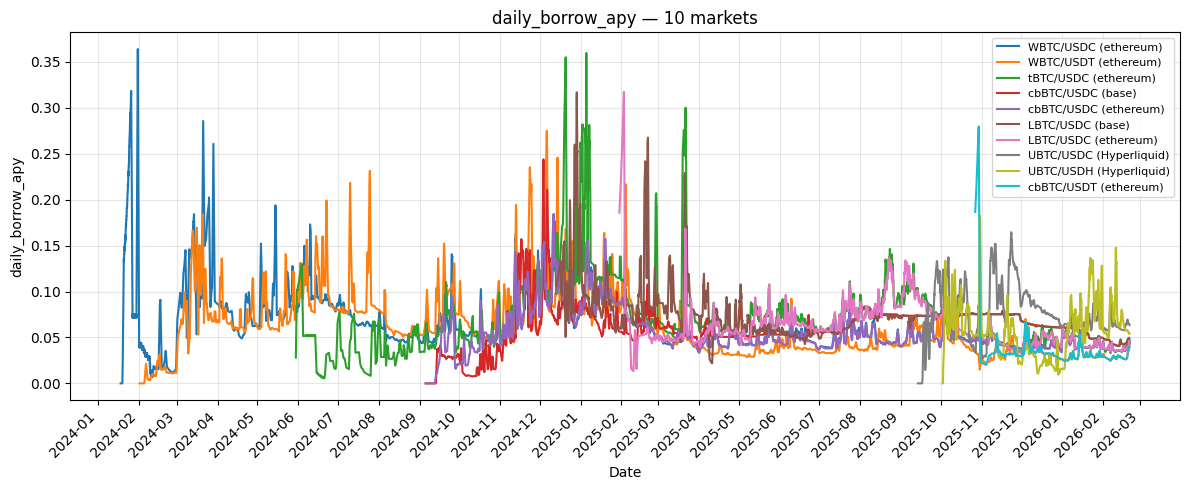

In [11]:
plot_compact(usd_markets["unique_key"].tolist(), filtered_markets,
             summary_df_filtered, metric="daily_borrow_apy")


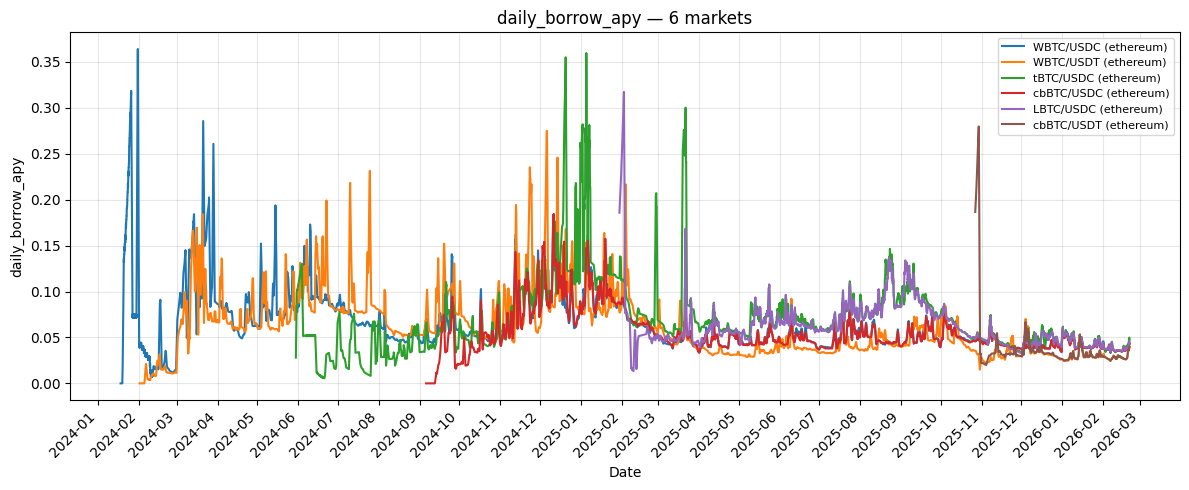

In [12]:
plot_compact(keys_usd_eth.tolist(), filtered_markets,
             summary_df_filtered, metric="daily_borrow_apy")


---
# Task 2: Borrow Rate Statistical Analysis & Forecasting

## Forecasting Methodology

### Why `log(1 + APY) × 100`?

Borrow rates are **state variables** (not additive flows), expressed as decimals (0.05 = 5% APY).
The correct variance-stabilising transform for multiplicative processes is `log1p`:

| Step | Formula | Reason |
|---|---|---|
| Transform | `s = log(1 + APY) × 100` | Stabilises multiplicative volatility; ×100 gives numerically stable EM |
| Difference | `Δs = s_t − s_{t−1}` | Removes non-stationarity within regimes |
| Model | AR(2) on `Δs` per regime | Captures mean reversion speed and persistence |
| Simulate | Monte Carlo on `Δs`, cumsum back to `s` | Propagates uncertainty correctly |
| Invert | `APY = exp(s / 100) − 1` | Exact inverse of the forward transform |

**Why `×100`:** `log1p` diffs at typical APY levels (3–40%) are O(0.003–0.03) —
too small for EM covariance estimation, causing SVD failures.
Scaling to percentage points gives diffs O(0.3–3), which is numerically stable.

---

### Why Markov-Switching AR(2)?

Borrow markets operate in two distinct regimes:

- **Regime 0 — Quiet:** low rates, near-unit-root persistence (φ ≈ 0.95), low variance
- **Regime 1 — Stressed:** elevated rates, faster mean reversion (φ ≈ 0.70), high variance

A simple AR model pools these and produces biased persistence estimates.
A simple HMM captures mean/variance shifts but ignores autocorrelation structure.
**Markov-switching AR(2)** captures both: regime-specific means and variances with shared AR dynamics.

Regime switching is governed by a transition matrix estimated via EM + BFGS:

```
P = [[p00,  1-p10],   p00 = P(stay in regime 0)
     [1-p00, p10 ]]   p10 = P(transition from regime 1 to regime 0)
```

Expected regime duration = `1 / (1 - p_ii)`.

---

### Forecasting pipeline

```
1. prepare_series()         → log1p(APY) × 100, daily resampled
2. fit_hmm_regimes()        → identify 2 regimes, diagnose ACF/PACF per regime
3. fit_forecast_model()     → Markov-AR(2) on first differences
4. simulate_paths()         → 10,000 Monte Carlo paths × 30 days
5. collect_forecast_table() → back-transform to APY, store per-market table
```

For **cross-market forecasting**, per-market models are fitted and AR/transition
parameters are pooled via median (robust to degenerate fits in thin markets).
Per-market variance is estimated from recent history to preserve idiosyncratic risk.


## 2.1 Inspect a single market

Using WBTC/USDC on Ethereum (`0x3a85e6`) as the reference market.
We work with `weekly_borrow_apy` transformed via `log(1 + APY) × 100` and resampled to daily (last value per day) to:
- Reduce intraday noise while preserving the rate's state-variable character
- Apply a variance-stabilising transform correct for decimal APY rates
- Scale to percentage points for numerical stability in EM estimation

In [14]:
market        = filtered_markets["0x3a85e6"]
weekly_series = prepare_series(market)

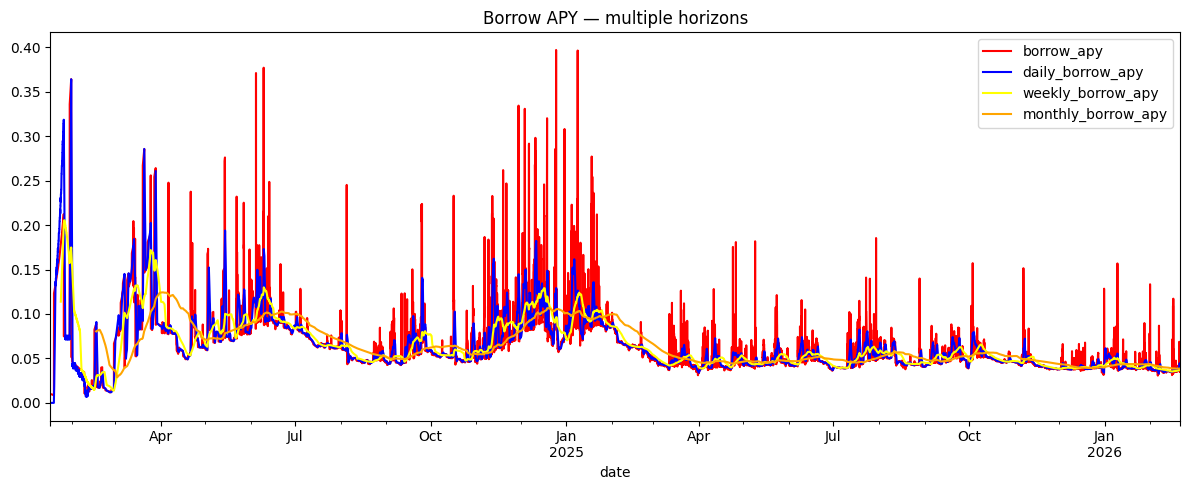

In [15]:
market[["borrow_apy","daily_borrow_apy","weekly_borrow_apy","monthly_borrow_apy"]].plot(
    figsize=(12, 5), color=["red","blue","yellow","orange"],
    title="Borrow APY — multiple horizons"
)
plt.tight_layout()
plt.show()

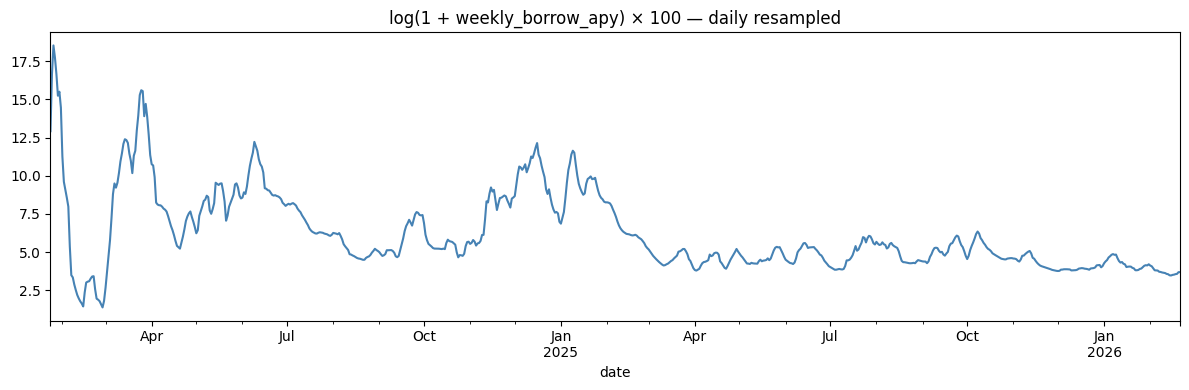

In [16]:
weekly_series.plot(
    figsize=(12, 4), color="steelblue",
    title="log(1 + weekly_borrow_apy) × 100 — daily resampled"
)
plt.tight_layout()
plt.show()


## 2.2 Stationarity & autocorrelation diagnostics

ADF rejects unit root; KPSS rejects stationarity. This contradiction indicates structural breaks / regime switching — each regime is likely stationary but the pooled series is not.

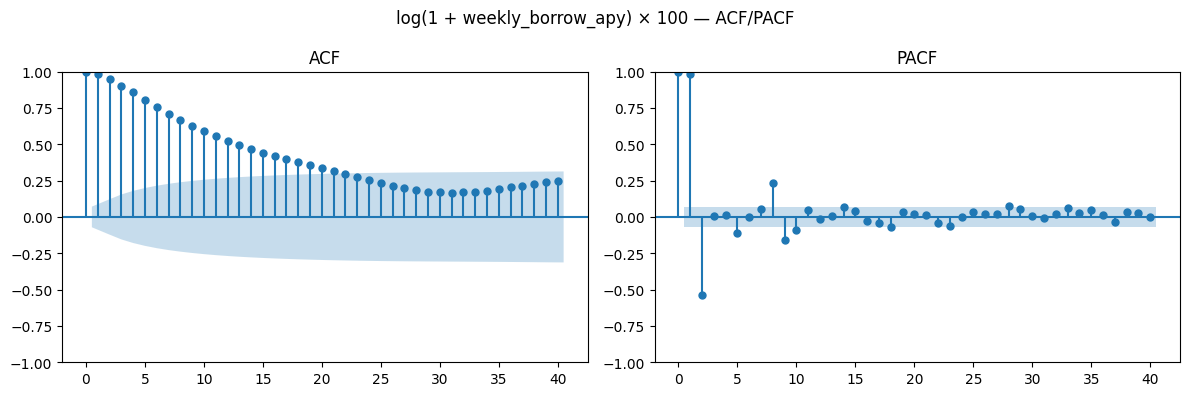

In [17]:
plot_acf_pacf(weekly_series, lags=40,
              title="log(1 + weekly_borrow_apy) × 100 — ACF/PACF")


In [18]:
print(stationarity_tests(weekly_series))

{'ADF Statistic': np.float64(-3.3112358564670017), 'ADF p-value': np.float64(0.01438364127739142), 'ADF lags': 19, 'ADF nobs': 740, 'KPSS Statistic': np.float64(1.6840033380915573), 'KPSS p-value': np.float64(0.01), 'KPSS lags': 17}


## 2.3 Regime detection (HMM)

Gaussian HMM with 2 states. Regimes are ordered by mean level:
- **Regime 0** — low-rate, high-persistence (quiet market)
- **Regime 1** — high-rate, faster mean reversion (stressed market)

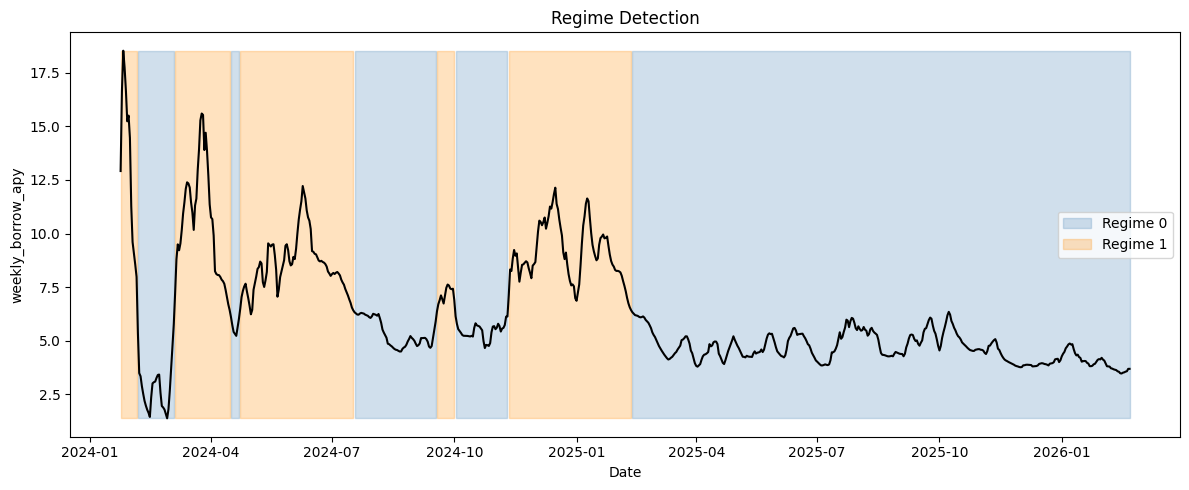

In [19]:
states, hmm_model = fit_hmm_regimes(weekly_series)


## 2.4 Per-regime ACF / PACF

Both regimes show AR(2) structure (strong lag-1 PACF, negative lag-2 PACF).
Regime 0 is more persistent (near unit root); Regime 1 mean-reverts faster.

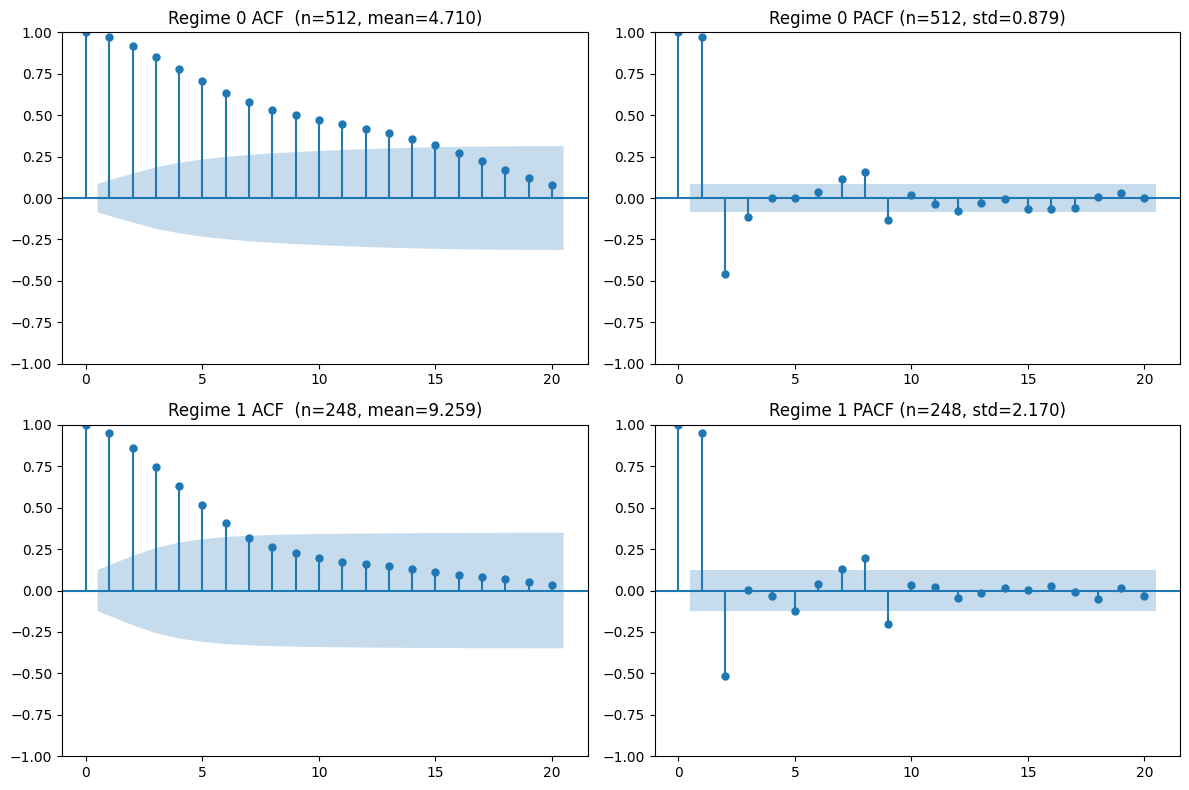

In [20]:
plot_acf_pacf_by_regime(weekly_series, states, lags=20)


## 2.5 Stationarity within regimes

In [21]:
stationarity_by_regime(weekly_series, states, min_length=30)



Regime 0: 5 episodes, 3 with n>=30
  [2024-07-18 to 2024-09-17] n=62 | ADF p=0.2418 KPSS p=0.0110
  [2024-10-02 to 2024-11-10] n=40 | ADF p=0.1139 KPSS p=0.1000
  [2025-02-12 to 2026-02-21] n=375 | ADF p=0.0352 KPSS p=0.0100

Regime 1: 5 episodes, 3 with n>=30
  [2024-03-05 to 2024-04-15] n=42 | ADF p=0.8788 KPSS p=0.1000
  [2024-04-23 to 2024-07-17] n=86 | ADF p=0.3402 KPSS p=0.1000
  [2024-11-11 to 2025-02-11] n=93 | ADF p=0.1384 KPSS p=0.1000


## 2.6 Statistical summary across all markets

Runs ADF, KPSS, moments, and ACF/PACF separately for above- and below-target utilization subsets of every candidate market.

In [24]:
all_stats = analyze_all_markets(filtered_markets, rate_col="borrow_apy")

merged = pd.merge(
    all_stats.reset_index(),
    selected_markets[["network", "unique_key", "market"]],
    left_on="market", right_on="unique_key",
    how="left", suffixes=("_stats", "_meta"),
)
display(merged.head())

,market_stats,regime,mean,variance,skewness,excess_kurtosis,adf_stat,adf_pval,adf_lags_used,adf_crit_5pct,...,pacf_lag_4,pacf_lag_5,pacf_lag_6,pacf_lag_7,pacf_lag_8,pacf_lag_9,pacf_lag_10,network,unique_key,market_meta
0,0xbf02d6,full,0.0622,0.0009,3.4872,19.2297,-6.4064,0.0000,34.0000,-2.8619,...,0.1414,0.1673,0.0428,0.0605,0.1124,0.0302,0.0286,ethereum,0xbf02d6,LBTC/USDC
1,0xbf02d6,above_target,0.0763,0.0017,2.7684,9.9945,-4.7656,0.0001,27.0000,-2.8623,...,0.1854,0.0094,0.0571,0.0885,0.0268,0.0723,0.0344,ethereum,0xbf02d6,LBTC/USDC
2,0xbf02d6,below_target,0.0532,0.0003,0.5004,-0.1813,-2.4524,0.1275,12.0000,-2.8620,...,0.0777,0.0214,0.0645,0.0523,0.0115,-0.0034,-0.0141,ethereum,0xbf02d6,LBTC/USDC
3,0x9103c3,full,0.0613,0.0007,2.3714,17.2986,-5.9557,0.0000,41.0000,-2.8618,...,0.0815,0.0836,0.0838,0.0509,0.0183,0.0118,0.0387,base,0x9103c3,cbBTC/USDC
4,0x9103c3,above_target,0.0702,0.0008,2.9946,16.7950,-4.2964,0.0005,35.0000,-2.8620,...,0.1018,0.1063,0.0904,0.0674,-0.0108,0.0016,-0.0379,base,0x9103c3,cbBTC/USDC


In [25]:
above_target_stats = all_stats[all_stats.index.get_level_values("regime") == "above_target"]
below_target_stats = all_stats[all_stats.index.get_level_values("regime") == "below_target"]

display(above_target_stats[
    ["stationary", "ci_band_95"] +
    [f"acf_lag_{i}"  for i in range(1, 6)] +
    [f"pacf_lag_{i}" for i in range(1, 6)]
].head(10))

,,stationary,ci_band_95,acf_lag_1,acf_lag_2,acf_lag_3,acf_lag_4,acf_lag_5,pacf_lag_1,pacf_lag_2,pacf_lag_3,pacf_lag_4,pacf_lag_5
market,regime,,,,,,,,,,,,
0xbf02d6,above_target,1.0000,0.0326,0.7347,0.7287,0.6760,0.6827,0.6239,0.7349,0.4109,0.1542,0.1854,0.0094
0x9103c3,above_target,-1.0000,0.0240,0.8978,0.8753,0.8359,0.8177,0.8035,0.8979,0.3577,0.0599,0.1018,0.1063
0x45af9c,above_target,-1.0000,0.0479,0.7832,0.6901,0.6370,0.5960,0.5752,0.7837,0.1989,0.1308,0.0827,0.0958
0x64d65c,above_target,-1.0000,0.0276,0.8534,0.8079,0.7697,0.7374,0.7184,0.8536,0.2933,0.1299,0.0746,0.0886
0xe4cfbe,above_target,-1.0000,0.0253,0.8867,0.8509,0.8303,0.8094,0.8005,0.8868,0.3032,0.1846,0.0982,0.1171
0x1f97b6,above_target,-1.0000,0.0505,0.7632,0.6457,0.5714,0.5546,0.5244,0.7637,0.1518,0.0928,0.1562,0.0565
0xa921ef,above_target,-1.0000,0.0258,0.9266,0.8770,0.8461,0.8185,0.7935,0.9267,0.1307,0.1342,0.0575,0.0417
0x45671f,above_target,0.0000,0.0718,0.9668,0.9513,0.9361,0.9187,0.9035,0.9681,0.2658,0.0785,-0.0179,0.0156
0x52a2a3,above_target,-1.0000,0.0274,0.8504,0.7782,0.7262,0.6796,0.6424,0.8506,0.1991,0.1015,0.0470,0.0453


## 2.7 Fit Markov-switching AR(2) forecast model

Model on first-differenced log series. `switching_ar=False` (shared AR coefficients), `switching_variance=True` (regime-specific volatility). AR(2) confirmed by AIC vs AR(1): −3029 vs −2719.

In [26]:
res, diff, series = fit_forecast_model(weekly_series)


                         Markov Switching Model Results                         
Dep. Variable:        weekly_borrow_apy   No. Observations:                  757
Model:             MarkovAutoregression   Log Likelihood                 239.919
Date:                  Wed, 25 Mar 2026   AIC                           -463.838
Time:                          13:57:19   BIC                           -426.803
Sample:                      01-25-2024   HQIC                          -449.574
                           - 02-21-2026                                         
Covariance Type:                 approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0339      0.012     -2.826      0.005      -0.057      -0.010
sigma2         0.0080      0.001    

## 2.8 Single-market 30-day forecast

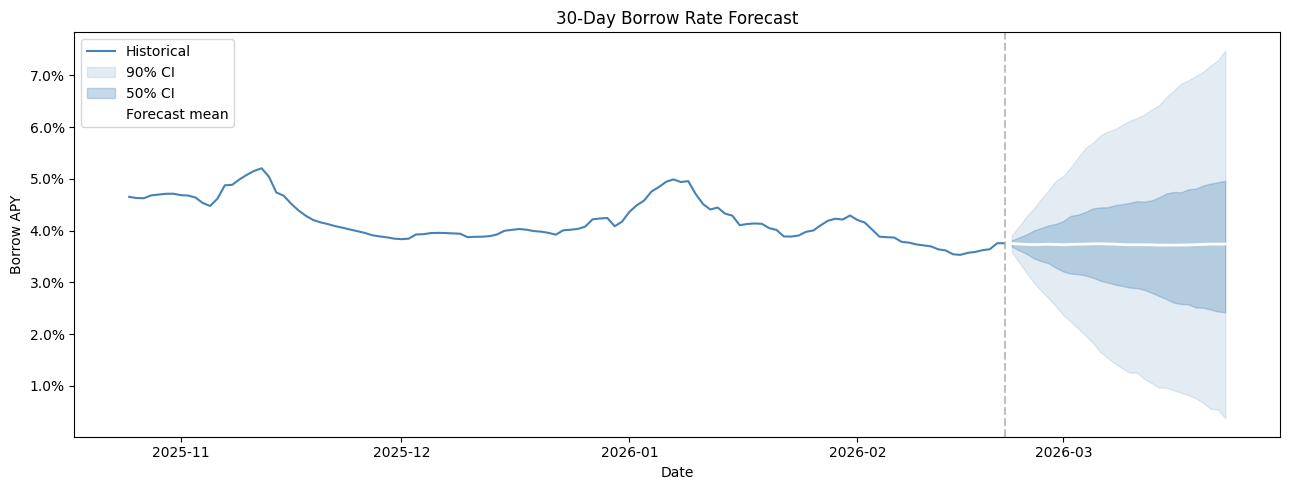

In [27]:
forecast_df = simulate_paths(res, weekly_series, horizon=30, n_sims=1000)
plot_forecast(weekly_series, forecast_df, lookback_days=120)


In [28]:
display(forecast_df.head(10))

,mean,ci_5,ci_25,ci_75,ci_95
2026-02-22,0.0375,0.0358,0.0369,0.0381,0.0392
2026-02-23,0.0374,0.0339,0.0362,0.0387,0.0409
2026-02-24,0.0373,0.0319,0.0355,0.0393,0.0428
2026-02-25,0.0373,0.0299,0.0346,0.0400,0.0443
2026-02-26,0.0373,0.0284,0.0341,0.0405,0.0461
2026-02-27,0.0374,0.0269,0.0337,0.0410,0.0478
2026-02-28,0.0373,0.0254,0.0328,0.0413,0.0496
2026-03-01,0.0373,0.0237,0.0321,0.0419,0.0506
2026-03-02,0.0374,0.0224,0.0317,0.0429,0.0522
2026-03-03,0.0374,0.0211,0.0316,0.0431,0.0542


## 2.9 Fit models across all markets & extract shared parameters

Fit per-market, then take median AR and transition parameters as shared estimates. Median is robust to degenerate fits in thin markets.

In [29]:
results, series_dict = fit_per_market_models(filtered_markets)
shared_params        = extract_shared_params(results)

Fitted 0x3a85e6: AIC=-463.8
ar.L1: median=0.6640  min=0.6160  max=0.9645  n=10
ar.L2: median=-0.0127  min=-0.1037  max=0.1752  n=10
p[0->0]: median=0.9496  min=0.8822  max=0.9868  n=10
p[1->0]: median=0.0796  min=0.0238  max=0.7440  n=10


## 2.10 Forecast all markets & collect output table

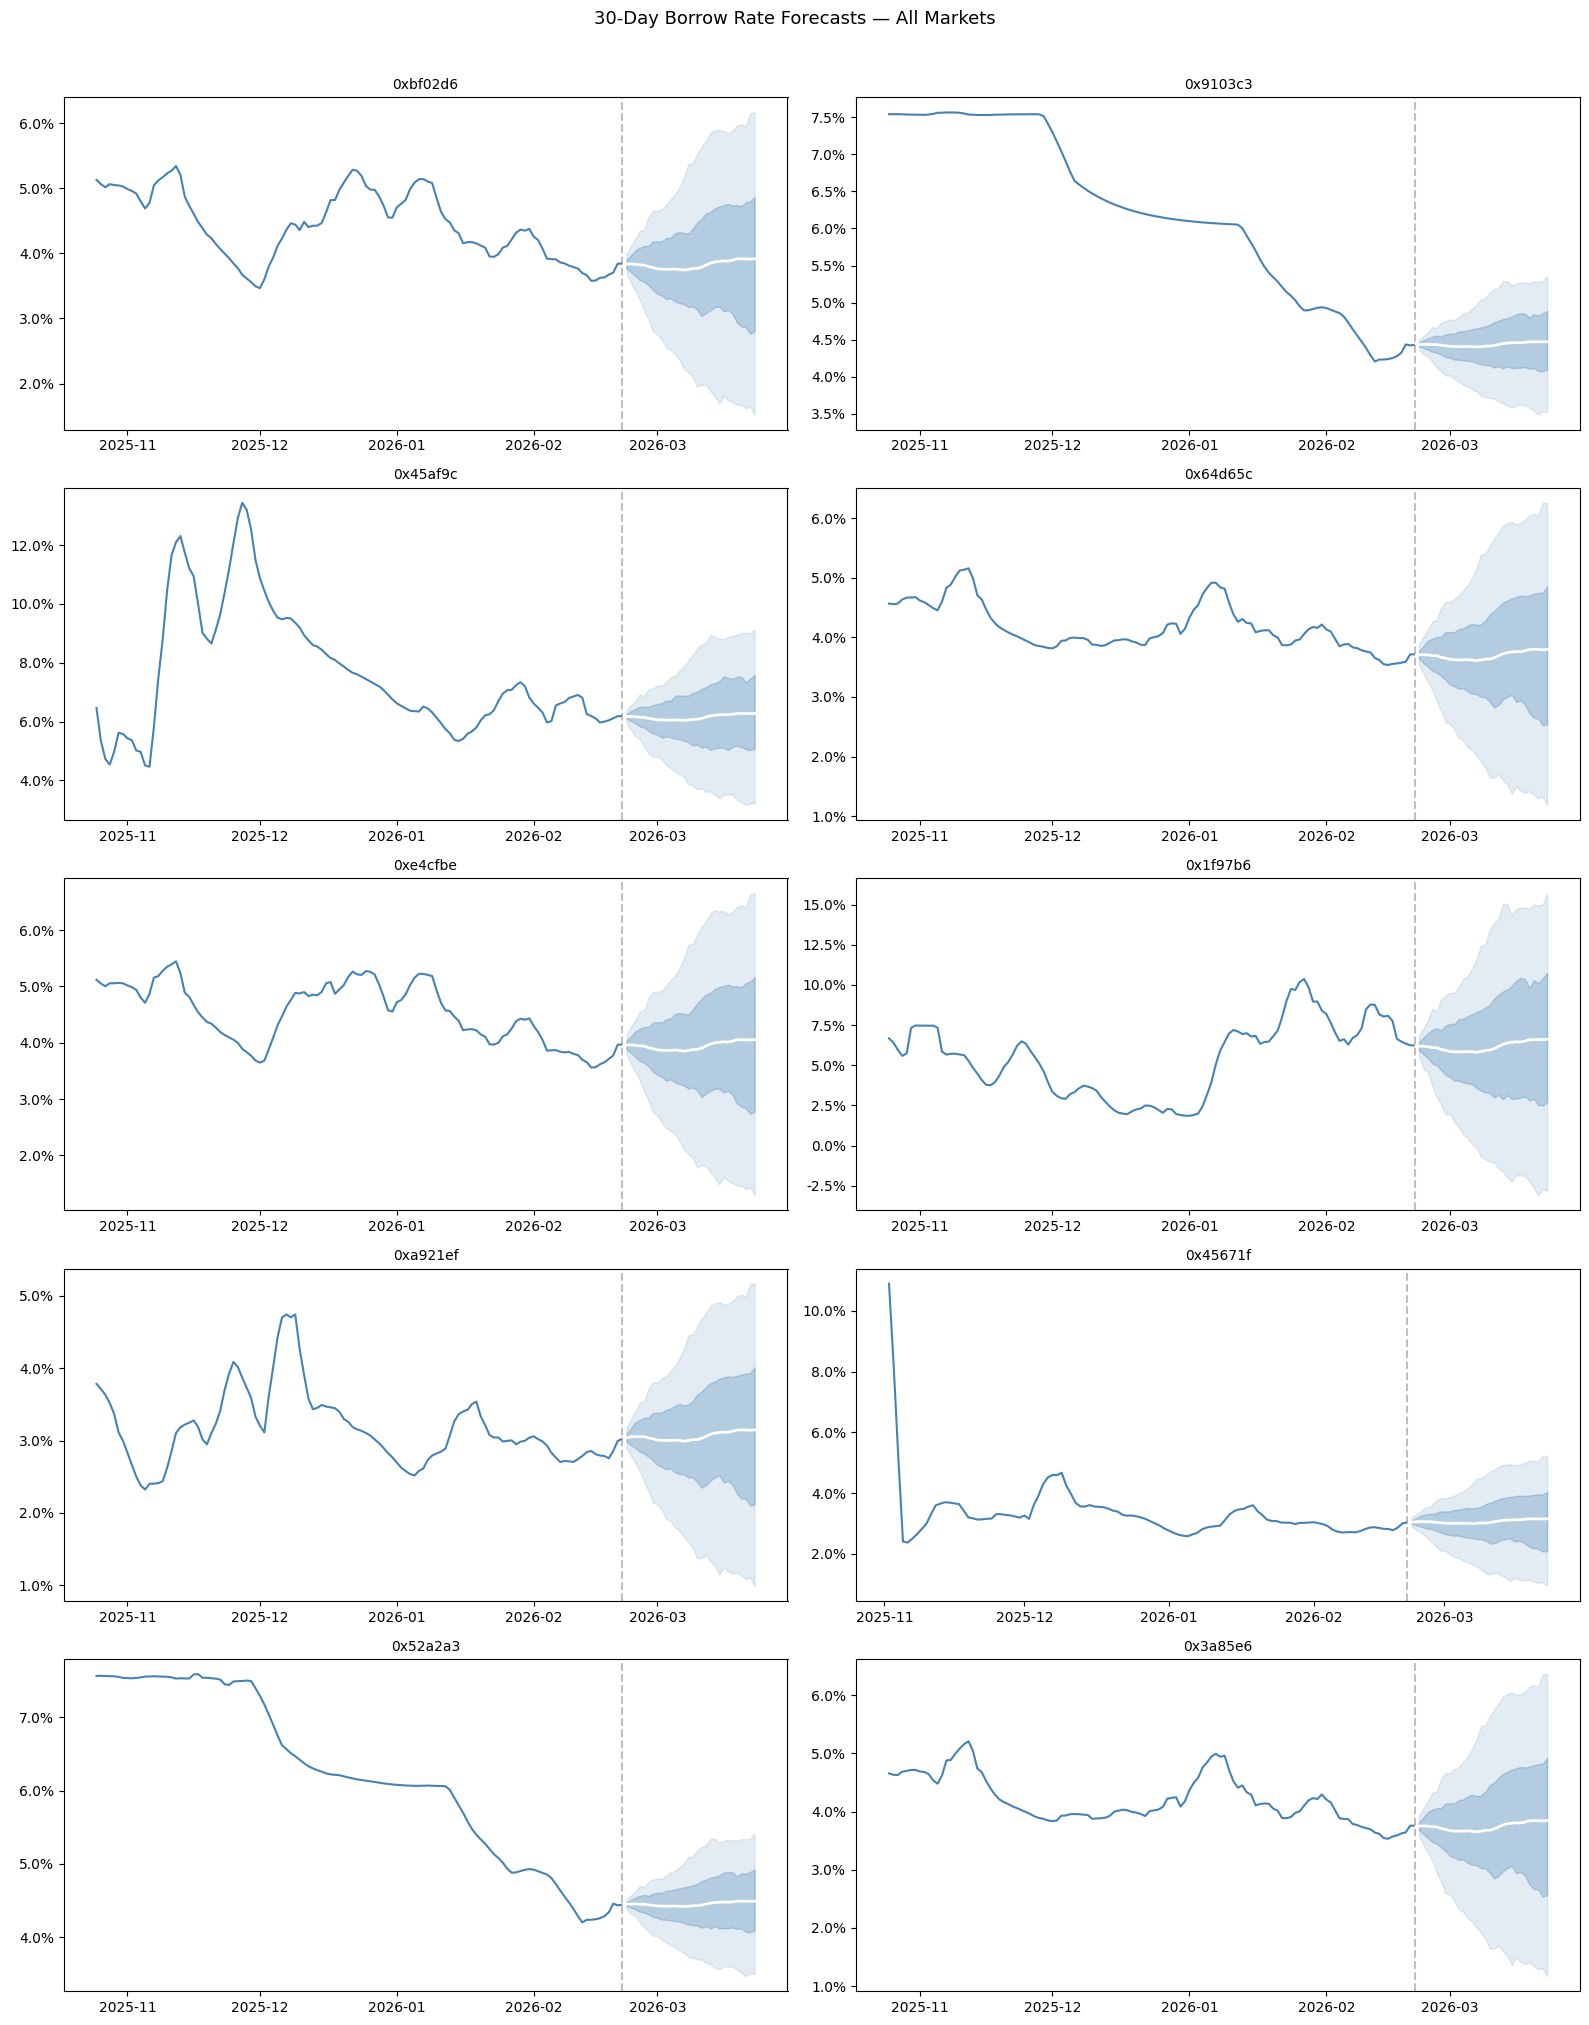

In [30]:
forecasts = forecast_all_markets_shared(shared_params, series_dict,
                                              horizon=30, n_sims=100)
plot_all_forecasts(series_dict, forecasts, lookback_days=120)


In [31]:
table   = collect_forecast_table(forecasts)
summary = print_forecast_summary(table)


market_id  30d_mean_%  5th_pct_%  95th_pct_%
 0x1f97b6      6.6100    -2.8200     15.7000
 0x3a85e6      3.8500     1.1700      6.3600
 0x45671f      3.1500     0.9400      5.2200
 0x45af9c      6.2700     3.2100      9.1200
 0x52a2a3      4.4900     3.5000      5.4100
 0x64d65c      3.8000     1.1900      6.2600
 0x9103c3      4.4700     3.5200      5.3500
 0xa921ef      3.1500     0.9900      5.1700
 0xbf02d6      3.9200     1.5200      6.1700
 0xe4cfbe      4.0600     1.2900      6.6600


In [32]:
display(table.head(20))

,market_id,date,mean,ci_5,ci_25,ci_75,ci_95,mean_pct,ci_5_pct,ci_25_pct,ci_75_pct,ci_95_pct
0,0xbf02d6,2026-02-22,0.0384,0.0369,0.0378,0.0390,0.0399,3.8400,3.6900,3.7800,3.9000,3.9900
1,0xbf02d6,2026-02-23,0.0384,0.0355,0.0371,0.0397,0.0411,3.8400,3.5500,3.7100,3.9700,4.1100
2,0xbf02d6,2026-02-24,0.0383,0.0343,0.0366,0.0405,0.0422,3.8300,3.4300,3.6600,4.0500,4.2200
3,0xbf02d6,2026-02-25,0.0382,0.0329,0.0359,0.0409,0.0435,3.8200,3.2900,3.5900,4.0900,4.3500
4,0xbf02d6,2026-02-26,0.0382,0.0312,0.0356,0.0411,0.0437,3.8200,3.1200,3.5600,4.1100,4.3700
5,0xbf02d6,2026-02-27,0.0380,0.0298,0.0351,0.0411,0.0456,3.8000,2.9800,3.5100,4.1100,4.5600
6,0xbf02d6,2026-02-28,0.0378,0.0280,0.0344,0.0418,0.0466,3.7800,2.8000,3.4400,4.1800,4.6600
7,0xbf02d6,2026-03-01,0.0376,0.0275,0.0338,0.0418,0.0465,3.7600,2.7500,3.3800,4.1800,4.6500
8,0xbf02d6,2026-03-02,0.0376,0.0267,0.0335,0.0419,0.0468,3.7600,2.6700,3.3500,4.1900,4.6800
9,0xbf02d6,2026-03-03,0.0375,0.0256,0.0330,0.0423,0.0474,3.7500,2.5600,3.3000,4.2300,4.7400


---
# Task 3: Market Impact Model (AdaptiveCurveIRM)

## 3.1 Utilization → borrow rate relationship

Morpho's AdaptiveCurveIRM produces a kinked rate curve:
- **Below target** (u < 0.9): gentle slope
- **Above target** (u > 0.9): steep slope (4× steeper)

The equilibrium rate at target (`borrow_rate_at_target_utilization`) drifts upward when utilization persistently exceeds target. This causes two distinct point clouds in the scatter — one pre-2025 (higher equilibrium) and one post-2025 (lower equilibrium after rate drift settled).

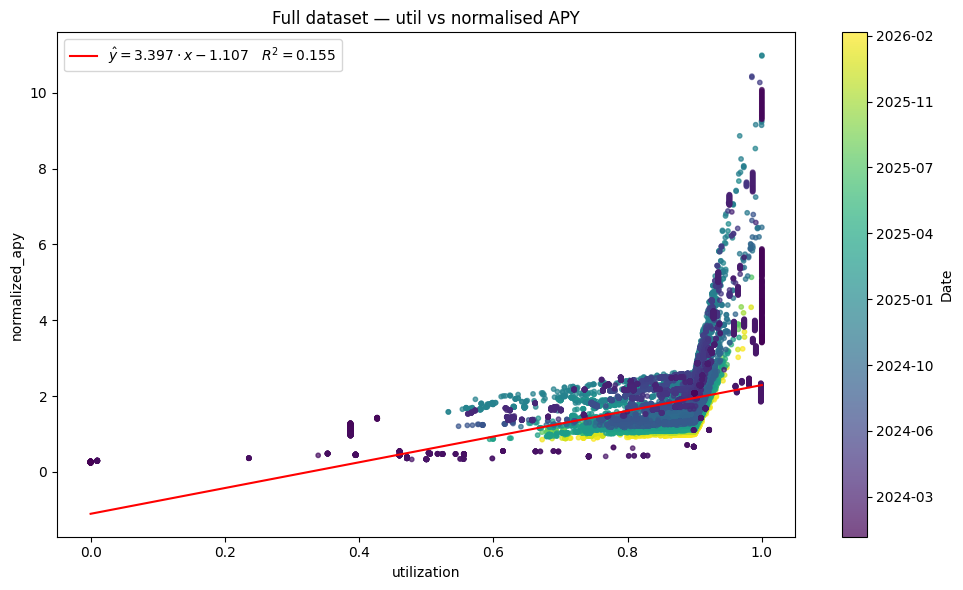

In [33]:
rates_ts = filtered_markets["0x3a85e6"].copy()
rates_ts["normalized_apy"] = rates_ts["borrow_apy"] / rates_ts["borrow_rate_at_target_utilization"]
plot_utilization_rate_scatter(rates_ts, title="Full dataset — util vs normalised APY")

In [34]:
# Post-June 2025 only (stable equilibrium period)
rates_ts_recent = rates_ts.loc[rates_ts.index > "2025-06-01"].copy()
target          = rates_ts_recent["target_utilization"].iloc[0]
rates_ts_above  = rates_ts_recent[
    (rates_ts_recent["utilization"] >= target) &
    (rates_ts_recent["utilization"] <  1.0)
]
rates_ts_below  = rates_ts_recent[rates_ts_recent["utilization"] < target]

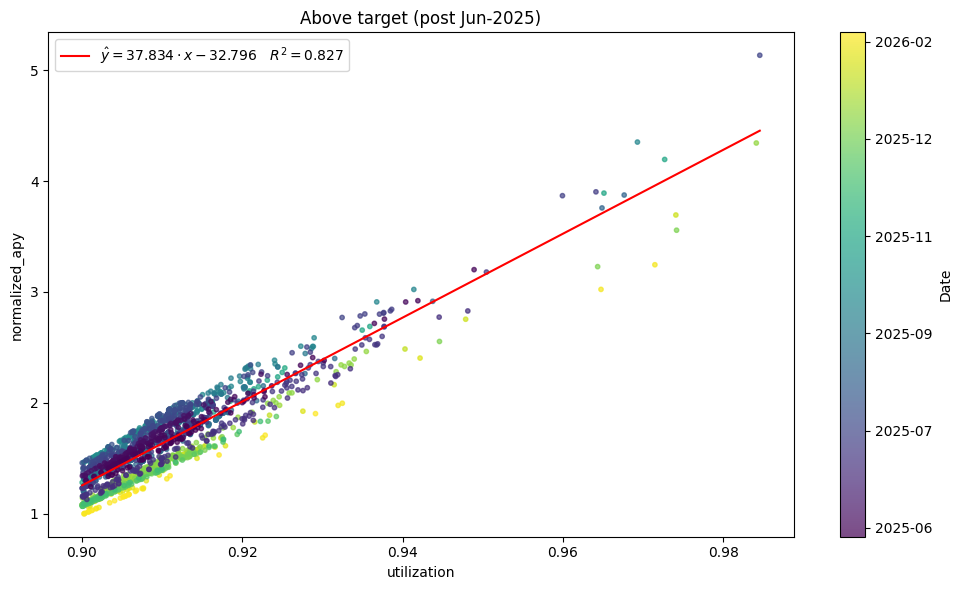

In [35]:
plot_utilization_rate_scatter(rates_ts_above, title="Above target (post Jun-2025)")

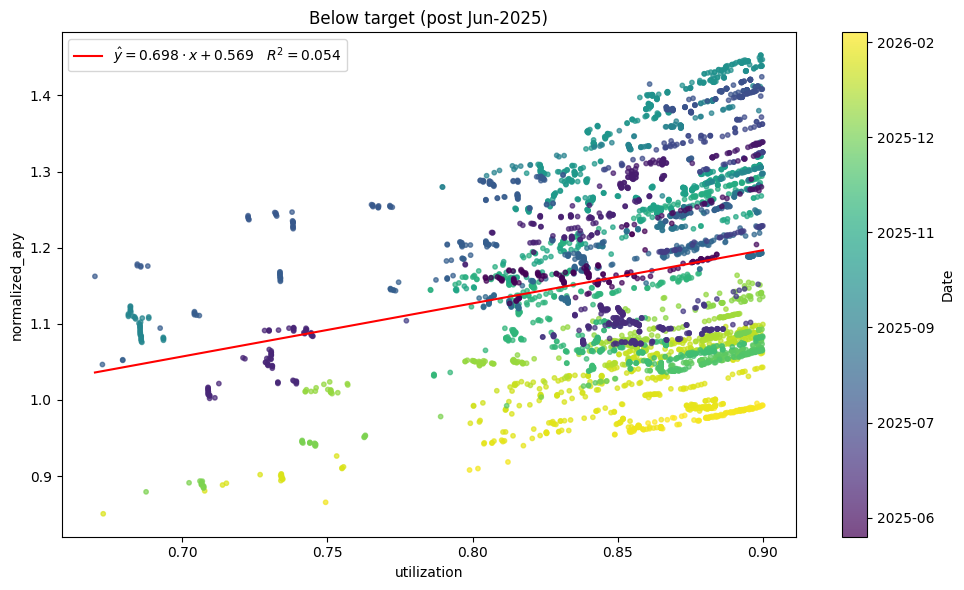

In [36]:
plot_utilization_rate_scatter(rates_ts_below, title="Below target (post Jun-2025)")

## 3.2 OLS fit: empirical IRM curve segments

In [37]:
res_above = fit_ols(rates_ts_above)
res_below = fit_ols(rates_ts_below)

print("Above target:")
print(f"  slope={res_above['slope']:.3f}  intercept={res_above['intercept']:.3f}  R²={res_above['r_squared']:.3f}")
print("Below target:")
print(f"  slope={res_below['slope']:.3f}  intercept={res_below['intercept']:.3f}  R²={res_below['r_squared']:.3f}")


Above target:
  slope=37.834  intercept=-32.796  R²=0.827
Below target:
  slope=0.698  intercept=0.569  R²=0.054


## 3.3 Analytical IRM curve vs empirical

The Morpho IRM uses fixed constants from `ConstantsLib.sol`:

| Parameter | Value |
|---|---|
| `CURVE_STEEPNESS` | 4.0 |
| `TARGET_UTILIZATION` | 0.9 |

**Curve logic (`_borrowRate()`):**
```
err = (u - 0.9) / 0.9   if u ≤ 0.9   → coeff = 1 - 1/C = 0.75
err = (u - 0.9) / 0.1   if u > 0.9   → coeff = C - 1  = 3.0
rate = (coeff × err + 1) × rateAtTarget
```

The equilibrium rate `rateAtTarget` drifts via a separate adaptive mechanism (speed controller in `AdaptiveCurveIRM`) — this is Layer 2, operating on a timescale of days.

## 3.4 Rate impact of incremental borrow demand

Models the immediate utilization and rate change from adding a fixed USD borrow amount, using the analytical IRM curve with current market state.

In [38]:
market_snapshots = btc_data_clean[btc_data_clean["unique_key"].str.contains("0x3a85e6")]

state = market_state_from_snapshot(market_snapshots)
print("Current market state:")
for k, v in state.items():
    print(f"  {k}: {v}")


Current market state:
  current_supply_usd: 96939281.57
  current_utilization: 0.8264916398430867
  current_borrow_apy: 0.032039539
  rate_at_target: 0.034165125
  target_utilization: 0.9
  available_usd: 16819775.779999986
  amount_to_target: 7125847.62


In [39]:
impact = run_impact_scenarios(
    market_snapshots,
    unique_key     = "0x3a85e6",
    add_borrow_usd = [500_000, 2_000_000, 5_000_000, 10_000_000],
)
display(impact)

,added_borrow_usd,new_utilization,borrow_rate,available_liquidity_usd
0,500000,0.8316,0.0322,"16,319,775.7800"
1,2000000,0.8471,0.0327,"14,819,775.7800"
2,5000000,0.8781,0.0335,"11,819,775.7800"
3,10000000,0.9296,0.0646,"6,819,775.7800"


---
# Task 4: Portfolio Optimisation

## 4.0 Methodology

### What we are solving

Distribute **$10M of BTC collateral** across N Morpho markets to minimise
the **true 30-day borrowing cost in USD**.

---

### Decision variable

$$x_i \;\text{= collateral allocated to market } i \text{ (USD)}, \quad \sum_i x_i = \$10M$$

The borrow amount in each market follows directly from the operating LTV:

$$b_i = x_i \times \text{safe\_ltv}_i, \qquad \text{safe\_ltv}_i = 0.75 \times \text{LLTV}_i$$

LTV is held **fixed** — optimising over both collateral and LTV adds a dimension
without changing the solution, since the safety constraint already tightly
determines the operating LTV.

**Why 75% of LLTV?**
LLTV is the liquidation threshold. For WBTC/USDC, LLTV = 0.86, so safe\_ltv = 0.645.
A 25% BTC price drop brings the actual position LTV from 0.645 to exactly 0.86 —
the liquidation boundary. BTC can drop 20–25% intraday in stress; this buffer is
the minimum acceptable margin at this position size.

---

### How our borrow shifts the rate — Task 3 market impact

Depositing BTC goes into the **collateral vault**, not the lending pool.
USDC supply is unchanged. Our borrow raises utilization:

$$u_i^{\text{new}} = \frac{B_i^{\text{exist}} + b_i}{S_i}$$

The IRM curve gives the rate shift caused by our position:

$$\Delta r_i = \underbrace{f(u_i^{\text{new}}) \times \text{anchor}_i}_{\text{rate after our borrow}} - \underbrace{f(u_i^{\text{current}}) \times \text{anchor}_i}_{\text{current market rate}}$$

where $f(u)$ is the piecewise linear IRM curve (C=4, target=0.9, from `ConstantsLib.sol`):

$$f(u) = \begin{cases}(0.75 \times err + 1) & u \leq 0.9 \\ (3.0 \times err + 1) & u > 0.9\end{cases}, \qquad err = \frac{u - 0.9}{1 - 0.9 \text{ or } 0.9}$$

$\Delta r_i$ is the **permanent upward shift** our position adds to every day
of the forecast path for as long as we hold the position.

---

### Why we use the forecast path — not analytical anchor drift

An earlier version modelled the average rate by projecting the anchor forward:

$$\text{anchor}(t) = \text{anchor}(0) \times e^{\frac{50}{365} \times err \times t}$$

This assumes utilization stays constant and rates move **monotonically in one direction**.
In practice rates do not behave this way — they regime-switch, mean-revert, and spike
and recover. The Markov-switching AR(2) forecast from Task 2 already captures all of that.

**The correct approach separates two concerns:**

| Component | Answers | Source |
|---|---|---|
| Forecast path | What will this market's rate do over 30 days regardless of us? | Task 2: MS-AR(2) Monte Carlo mean |
| Rate impact | How much does our position permanently shift the rate? | Task 3: IRM curve |

Combining them gives the expected rate path for market $i$ on day $t$:

$$\hat{r}_i(t) = \underbrace{\text{forecast\_mean}_i(t)}_{\text{market dynamics}} + \underbrace{\Delta r_i}_{\text{our impact}}, \quad t = 1 \ldots 30$$

$$\bar{r}_i = \frac{1}{30} \sum_{t=1}^{30} \hat{r}_i(t)$$

---

### Objective function

$$\min_{x_1,\ldots,x_N} \sum_{i=1}^{N} \underbrace{x_i \times \text{ltv}_i}_{b_i} \times \bar{r}_i(b_i) \times \frac{30}{365}$$

This is **non-linear** because $\bar{r}_i$ depends on $b_i$ through the IRM curve.
It is **convex** above target utilization — each additional dollar borrowed costs
more than the previous one. This convexity causes the optimizer to naturally
spread allocations across markets.

---

### Constraints

| Constraint | Formula | Rationale |
|---|---|---|
| Full deployment | $\sum x_i = \$10M$ | All capital must be working |
| Liquidity cap | $b_i \leq \text{available}_i$ | Cannot borrow more than exists |
| Min ticket | $x_i \geq \$200K$ or $x_i = 0$ | No micro-positions |
| Safety LTV | $\text{ltv}_i = 0.75 \times \text{LLTV}_i$ | Liquidation buffer |
| Feasibility | $u_i^{\text{current}} < \text{target}_i$ | Only markets with headroom |

**Why no hard utilization ceiling?**
The forecast-based cost function already prices above-target allocation correctly —
the forecast for a market near 90% shows elevated rates, and $\Delta r_i$ adds the
steeper-slope IRM cost on top. A hard cap collapses the feasible set and produces
trivially flat solutions.

**Why exclude markets already at or above target?**
Any allocation starts on the steep side of the IRM curve with an already-stressed anchor.
Excluding them avoids numerical instability without losing any optimal solution.

---

### Solver

**SLSQP** — handles non-linear objectives with equality and inequality constraints.
Starting point: equal weight, clipped to liquidity bounds, renormalised to $10M.

## 4.1 Prepare market state

In [40]:
TOTAL_CAPITAL  = 10_000_000
MIN_ALLOCATION =    200_000
HORIZON_DAYS   =         30

rows = []
for key, forecast_df in forecasts.items():
    if key not in series_dict:
        continue
    snap = btc_data_clean[btc_data_clean["unique_key"].str.contains(key)]
    if snap.empty:
        continue
    snap = snap.sort_values("retrieved_at_utc").iloc[-1]

    supply   = float(snap["current_supply_usd"])   # USDC deposited by lenders
    borrow   = float(snap["current_borrow_usd"])   # USDC currently borrowed
    lltv     = float(snap["lltv"])
    rat      = float(snap["borrow_rate_at_target_utilization"])
    target_u = float(snap["target_utilization"])

    rows.append({
        "market_id":      key,
        "supply_usd":     supply,
        "borrow_usd":     borrow,
        "available_usd":  supply - borrow,
        "current_util":   borrow / supply if supply > 0 else np.nan,
        "lltv":           lltv,
        "safe_ltv":       lltv * 0.75,
        "rate_at_target": rat,
        "target_util":    target_u,
        "forecast_apy":   float(forecast_df["mean"].mean()),
    })

mkt = pd.DataFrame(rows).set_index("market_id")
mkt = pd.concat([keymap, mkt], axis=1).dropna()

print(f"Total markets loaded: {len(mkt)}")
display(mkt[[
    "market_network", "supply_usd", "available_usd",
    "current_util", "target_util", "lltv", "safe_ltv", "forecast_apy"
]].round(4))

,market_network,supply_usd,available_usd,current_util,target_util,lltv,safe_ltv,forecast_apy
0x1f97b6,UBTC/USDH_Hyperliquid,"1,574,188.8540","206,158.1270",0.8690,0.9000,0.7700,0.5775,0.0616
0x3a85e6,WBTC/USDC_ethereum,"96,939,281.5700","16,819,775.7800",0.8265,0.9000,0.8600,0.6450,0.0374
0x45671f,cbBTC/USDT_ethereum,"10,633,812.9200","2,669,631.9360",0.7489,0.9000,0.8600,0.6450,0.0306
0x45af9c,UBTC/USDC_Hyperliquid,"3,100,544.9690","579,548.9720",0.8131,0.9000,0.7700,0.5775,0.0615
0x52a2a3,LBTC/USDC_base,"164,823.1396","16,551.1786",0.8996,0.9000,0.8600,0.6450,0.0445
0x64d65c,cbBTC/USDC_ethereum,"477,066,035.6000","82,272,874.6000",0.8275,0.9000,0.8600,0.6450,0.0370
0x9103c3,cbBTC/USDC_base,"1,027,474,637.0000","102,795,343.1000",0.9000,0.9000,0.8600,0.6450,0.0444
0xa921ef,WBTC/USDT_ethereum,"69,045,394.7800","17,228,151.7600",0.7505,0.9000,0.8600,0.6450,0.0306
0xbf02d6,LBTC/USDC_ethereum,"5,072,947.0030","903,672.1220",0.8219,0.9000,0.8600,0.6450,0.0382
0xe4cfbe,tBTC/USDC_ethereum,"784,096.1092","142,675.6839",0.8180,0.9000,0.7700,0.5775,0.0395


## 4.2 Feasibility filter — exclude markets already at or above target

In [41]:
already_over = mkt["current_util"] >= mkt["target_util"]

print("Excluded markets (current_util >= target_util):")
for key, row in mkt[already_over].iterrows():
    print(f"  {key}  {row.get('market_network',''):<30s}  "
          f"util={row['current_util']:.4f}  target={row['target_util']:.2f}")

mkt_feasible = mkt[~already_over].copy()
print(f"\nFeasible: {len(mkt_feasible)}  excluded: {already_over.sum()}")

Excluded markets (current_util >= target_util):

Feasible: 10  excluded: 0


## 4.3 Solve optimisation

In [42]:
N       = len(mkt_feasible)
ltv_arr = mkt_feasible["safe_ltv"].values

# Upper bound: collateral such that borrow ≤ available liquidity
# No hard util ceiling — forecast cost function handles above-target pricing
upper = mkt_feasible["available_usd"].values / np.where(ltv_arr > 0, ltv_arr, 1.0)
upper = np.minimum(upper, TOTAL_CAPITAL)

print("Collateral ceilings (from liquidity caps):")
for i, (key, row) in enumerate(mkt_feasible.iterrows()):
    print(f"  {key}  {row.get('market_network',''):<30s}  "
          f"available=${row['available_usd']:>14,.0f}  "
          f"max_collateral=${upper[i]:>14,.0f}")

constraints = [{"type": "eq", "fun": lambda x: x.sum() - TOTAL_CAPITAL}]
bounds      = [(0.0, float(u)) for u in upper]

x0 = np.clip(np.full(N, TOTAL_CAPITAL / N), 0.0, upper)
x0 = x0 / x0.sum() * TOTAL_CAPITAL

result = minimize(
    hcl.cost_30d_forecast,
    x0,
    args=(mkt_feasible, ltv_arr, forecasts, HORIZON_DAYS),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={"ftol": 1e-12, "maxiter": 2000},
)

print(f"\nOptimisation status : {result.message}")
print(f"Converged           : {result.success}")
print(f"Iterations          : {result.nit}")
print(f"Objective (30d cost): ${result.fun:,.0f}")


Optimisation status : Optimization terminated successfully
Converged           : True
Iterations          : 658
Objective (30d cost): $18,840


## 4.4 Post-process results

In [43]:
x_opt = result.x.copy()
x_opt[x_opt < MIN_ALLOCATION] = 0.0
if x_opt.sum() > 0:
    x_opt = x_opt / x_opt.sum() * TOTAL_CAPITAL

alloc = mkt_feasible.copy()
alloc["collateral_usd"] = x_opt
alloc["borrow_usd_new"] = x_opt * ltv_arr
alloc["weight_pct"]     = x_opt / TOTAL_CAPITAL * 100

# New utilization — supply unchanged (BTC → collateral vault, not lending pool)
alloc["new_util"] = (alloc["borrow_usd"] + alloc["borrow_usd_new"]) / alloc["supply_usd"]

# Rate at entry: IRM curve at current anchor + new utilization
alloc["rate_at_entry"] = [
    hcl.irm_curve(row["rate_at_target"], alloc.loc[key, "new_util"],
                  target_utilization=row["target_util"])
    for key, row in alloc.iterrows()
]

# Rate impact: the permanent shift our position adds to the forecast path
alloc["rate_impact"] = [
    hcl.compute_rate_impact(alloc.loc[key, "borrow_usd_new"], row)
    for key, row in alloc.iterrows()
]

# Forecast average rate: mean of the 30-day Task 2 forecast path (no impact)
alloc["forecast_avg_rate"] = [
    float(forecasts[key]["mean"].values[:HORIZON_DAYS].mean())
    if key in forecasts else row["forecast_apy"]
    for key, row in alloc.iterrows()
]

# Expected average rate = forecast path + our impact, floored at zero
alloc["expected_avg_rate"] = (alloc["forecast_avg_rate"] + alloc["rate_impact"]).clip(lower=0.0)

alloc["cost_30d_usd"]     = alloc["borrow_usd_new"] * alloc["expected_avg_rate"] * HORIZON_DAYS / 365
alloc["annual_cost_usd"]  = alloc["borrow_usd_new"] * alloc["expected_avg_rate"]
alloc["monthly_cost_usd"] = alloc["annual_cost_usd"] / 12

active = alloc[alloc["collateral_usd"] > 0].copy()
meta   = summary_df_filtered.set_index("unique_key")[["market", "network"]]
active = active.join(meta, how="left", rsuffix="_meta")

total_borrow  = active["borrow_usd_new"].sum()
total_30d     = active["cost_30d_usd"].sum()
total_monthly = active["monthly_cost_usd"].sum()
total_annual  = active["annual_cost_usd"].sum()
blended_entry = (active["borrow_usd_new"] * active["rate_at_entry"]).sum() / total_borrow
blended_avg   = total_annual / total_borrow if total_borrow > 0 else np.nan

print(f"Active markets          : {len(active)}")
print(f"Total collateral        : ${TOTAL_CAPITAL:,.0f}")
print(f"Total borrow            : ${total_borrow:,.0f}")
print(f"Blended rate at entry   : {blended_entry:.2%}  (IRM rate on day 0)")
print(f"Blended forecast avg    : {blended_avg:.2%}  (forecast + impact, 30-day mean)")
print(f"True 30-day cost        : ${total_30d:,.0f}")
print(f"Annualised monthly      : ${total_monthly:,.0f}")

Active markets          : 5
Total collateral        : $10,000,000
Total borrow            : $6,450,000
Blended rate at entry   : 3.16%  (IRM rate on day 0)
Blended forecast avg    : 3.55%  (forecast + impact, 30-day mean)
True 30-day cost        : $18,836
Annualised monthly      : $19,098


## 4.5 Allocation table

In [44]:
display(
    active[[
        "market", "network",
        "collateral_usd", "borrow_usd_new", "weight_pct",
        "current_util", "new_util",
        "forecast_avg_rate", "rate_impact", "expected_avg_rate",
        "cost_30d_usd",
    ]]
    .rename(columns={
        "market":             "Pair",
        "network":            "Network",
        "collateral_usd":     "Collateral (USD)",
        "borrow_usd_new":     "Borrow (USD)",
        "weight_pct":         "Weight (%)",
        "current_util":       "Util before",
        "new_util":           "Util after",
        "forecast_avg_rate":  "Forecast rate (no impact)",
        "rate_impact":        "Our impact",
        "expected_avg_rate":  "Expected avg rate",
        "cost_30d_usd":       "30d cost (USD)",
    })
    .style.format({
        "Collateral (USD)":          "{:,.0f}",
        "Borrow (USD)":              "{:,.0f}",
        "Weight (%)":                "{:.2f}",
        "Util before":               "{:.4f}",
        "Util after":                "{:.4f}",
        "Forecast rate (no impact)": "{:.4%}",
        "Our impact":                "{:.4%}",
        "Expected avg rate":         "{:.4%}",
        "30d cost (USD)":            "{:,.0f}",
    })
    .set_caption(
        f"Optimal allocation — ${TOTAL_CAPITAL/1e6:.0f}M BTC collateral | "
        f"Expected blended APY: {blended_avg:.2%} | "
        f"30-day cost: ${total_30d:,.0f}"
    )
)

,Pair,Network,Collateral (USD),Borrow (USD),Weight (%),Util before,Util after,Forecast rate (no impact),Our impact,Expected avg rate,30d cost (USD)
0x45671f,cbBTC/USDT,ethereum,"2,298,657","1,482,634",22.99,0.7489,0.8884,3.0617%,0.3535%,3.4152%,"4,162"
0x64d65c,cbBTC/USDC,ethereum,"2,603,556","1,679,294",26.04,0.8275,0.8311,3.6980%,0.0100%,3.7080%,"5,118"
0x9103c3,cbBTC/USDC,base,"1,209,798","780,320",12.10,0.9000,0.9007,4.4362%,0.0937%,4.5300%,"2,905"
0xa921ef,WBTC/USDT,ethereum,"3,493,965","2,253,607",34.94,0.7505,0.7831,3.0608%,0.0825%,3.1433%,"5,822"
0xbf02d6,LBTC/USDC,ethereum,"394,024","254,145",3.94,0.8219,0.8720,3.8248%,0.1438%,3.9686%,829


## 4.6 Naive benchmark

Compare optimal vs putting all $10M into the single cheapest market.

In [45]:
cheapest_key = mkt_feasible["forecast_apy"].idxmin()
cheapest_row = mkt_feasible.loc[cheapest_key]
naive_ltv    = cheapest_row["safe_ltv"]
naive_borrow = TOTAL_CAPITAL * naive_ltv

naive_impact       = hcl.compute_rate_impact(naive_borrow, cheapest_row)
naive_forecast_avg = float(forecasts[cheapest_key]["mean"].values[:HORIZON_DAYS].mean()) \
    if cheapest_key in forecasts else cheapest_row["forecast_apy"]
naive_avg_rate = max(naive_forecast_avg + naive_impact, 0.0)
naive_30d      = naive_borrow * naive_avg_rate * HORIZON_DAYS / 365
naive_monthly  = naive_borrow * naive_avg_rate / 12

print(f"Cheapest market (by forecast APY) : {cheapest_key}  "
      f"({cheapest_row.get('market_network', '')})")
print(f"Naive forecast rate (no impact)   : {naive_forecast_avg:.2%}")
print(f"Naive rate impact (full $10M here): +{naive_impact:.2%}")
print(f"Naive expected avg rate           : {naive_avg_rate:.2%}")
print(f"Naive 30-day cost                 : ${naive_30d:,.0f}")
print()
print(f"Optimal 30-day cost               : ${total_30d:,.0f}")
print(f"Saving vs naive                   : ${naive_30d - total_30d:,.0f}")
print(f"Saving (bps on blended rate)      : {(naive_avg_rate - blended_avg)*10000:.1f} bps")

Cheapest market (by forecast APY) : 0xa921ef  (WBTC/USDT_ethereum)
Naive forecast rate (no impact)   : 3.06%
Naive rate impact (full $10M here): +0.24%
Naive expected avg rate           : 3.30%
Naive 30-day cost                 : $17,478

Optimal 30-day cost               : $18,836
Saving vs naive                   : $-1,359
Saving (bps on blended rate)      : -25.6 bps


## 4.7 Sensitivity analysis

In [46]:
def run_sensitivity(label, mkt_mod, capital=TOTAL_CAPITAL):
    """Re-run optimisation with modified market state or AUM."""
    _over = mkt_mod["current_util"] >= mkt_mod["target_util"]
    _mkt  = mkt_mod[~_over].copy()
    _ltv  = _mkt["safe_ltv"].values
    _upper = np.minimum(
        _mkt["available_usd"].values / np.where(_ltv > 0, _ltv, 1.0),
        capital
    )
    _bounds = [(0.0, float(u)) for u in _upper]
    _cons   = [{"type": "eq", "fun": lambda x: x.sum() - capital}]
    _x0     = np.clip(np.full(len(_mkt), capital / len(_mkt)), 0.0, _upper)
    if _x0.sum() > 0:
        _x0 = _x0 / _x0.sum() * capital

    res = minimize(
        hcl.cost_30d_forecast, _x0,
        args=(_mkt, _ltv, forecasts, HORIZON_DAYS),
        method="SLSQP", bounds=_bounds, constraints=_cons,
        options={"ftol": 1e-12, "maxiter": 2000}
    )
    x = res.x.copy()
    x[x < MIN_ALLOCATION] = 0.0
    if x.sum() > 0:
        x = x / x.sum() * capital

    total_b  = sum(x[i] * _ltv[i] for i in range(len(x)))
    cost_30d = hcl.cost_30d_forecast(x, _mkt, _ltv, forecasts, HORIZON_DAYS)
    apy      = (cost_30d * 365 / HORIZON_DAYS) / total_b if total_b > 0 else np.nan

    return {
        "scenario":       label,
        "blended_apy_%":  round(apy * 100, 3),
        "30d_cost_usd":   round(cost_30d),
        "active_markets": int((x > 0).sum()),
        "converged":      res.success,
    }

scenarios = [{
    "scenario":       "Baseline ($10M)",
    "blended_apy_%":  round(blended_avg * 100, 3),
    "30d_cost_usd":   round(total_30d),
    "active_markets": len(active),
    "converged":      True,
}]

mkt_up = mkt_feasible.copy()
mkt_up["rate_at_target"] = mkt_up["rate_at_target"] + 0.01
scenarios.append(run_sensitivity("Rates +100bps", mkt_up))

mkt_dn = mkt_feasible.copy()
mkt_dn["rate_at_target"] = (mkt_dn["rate_at_target"] - 0.01).clip(lower=0.001)
scenarios.append(run_sensitivity("Rates -100bps", mkt_dn))

top_mkt = mkt_feasible["available_usd"].idxmax()
mkt_liq = mkt_feasible.copy()
mkt_liq.loc[top_mkt, "available_usd"] *= 0.5
scenarios.append(run_sensitivity(f"Liquidity -50% ({top_mkt})", mkt_liq))

scenarios.append(run_sensitivity("AUM $5M",  mkt_feasible, capital=5_000_000))
scenarios.append(run_sensitivity("AUM $20M", mkt_feasible, capital=20_000_000))

display(pd.DataFrame(scenarios))

,scenario,blended_apy_%,30d_cost_usd,active_markets,converged
0,Baseline ($10M),3.5530,18836,5,True
1,Rates +100bps,3.7440,19850,6,True
2,Rates -100bps,3.3120,17556,4,True
3,Liquidity -50% (0x9103c3),3.5530,18836,5,True
4,AUM $5M,3.1870,8448,2,True
5,AUM $20M,4.3220,45825,6,True


---
# Task 5: Final Output

## 5.1 Executive summary

In [47]:
RATE_THRESHOLD = 0.0100
UTIL_THRESHOLD = 0.95
REBAL_DAYS     = 30

summary_md = f"""
## Strategy Summary

### Blended cost vs naive

|  | Blended APY | 30-day cost (USD) |
|---|---|---|
| **Optimal allocation** | **{blended_avg:.2%}** | **{total_30d:,.0f}** |
| Naive (single cheapest market) | {naive_avg_rate:.2%} | {naive_30d:,.0f} |
| **Saving** | **{(naive_avg_rate - blended_avg)*10000:.0f} bps** | **{naive_30d - total_30d:,.0f}** |

Diversification reduces self-impact cost: putting the full $10M into one market
adds +{naive_impact*10000:.0f}bps of utilization impact, whereas spreading across
{len(active)} markets keeps each market's impact small.

---

### Predicted 30-day borrowing cost

- Total collateral deployed: ${TOTAL_CAPITAL:,.0f}
- Total borrow: ${total_borrow:,.0f}  (blended LTV: {total_borrow/TOTAL_CAPITAL:.2%})
- Rate at entry (day 0): {blended_entry:.2%}
- Expected blended APY (forecast + impact): {blended_avg:.2%}
- **30-day cost: ${total_30d:,.0f}**
- Annualised monthly: ${total_monthly:,.0f}

---

### Cost model

30-day rate = Task 2 forecast (MS-AR(2) mean path) + Task 3 market impact ($\Delta r_i$).
Rates can move in either direction — the forecast captures regime switching and
mean reversion. The impact term captures the permanent utilization shift from our position.

---

### Reallocation triggers

| Trigger | Threshold | Rationale |
|---|---|---|
| Rate drift | Any market moves >{RATE_THRESHOLD*10000:.0f}bps | Shifts cost optimum materially |
| Utilization | Any market util >{UTIL_THRESHOLD:.0%} | Approaching liquidity cliff |
| Time-based | Every {REBAL_DAYS} days | Forecast staleness, anchor drift |
| BTC price drop | >15% drawdown | LTV safety buffer may be breached |

---

### Key risks

| Risk | Impact | Mitigation |
|---|---|---|
| BTC collateral drop | LTV → liquidation | 75% LLTV buffer, daily monitoring |
| Rate spikes across markets | Cost exceeds forecast | Diversification across {len(active)} markets |
| Liquidity withdrawal | Available borrow shrinks | Utilization trigger forces reallocation |
| Forecast error | Actual cost diverges | Treat as ranking tool, not point estimate |
| Regime shift outside training data | MS-AR(2) misses tail | Sensitivity scenarios above |
"""
display(Markdown(summary_md))


## Strategy Summary

### Blended cost vs naive

|  | Blended APY | 30-day cost (USD) |
|---|---|---|
| **Optimal allocation** | **3.55%** | **18,836** |
| Naive (single cheapest market) | 3.30% | 17,478 |
| **Saving** | **-26 bps** | **-1,359** |

Diversification reduces self-impact cost: putting the full $10M into one market
adds +24bps of utilization impact, whereas spreading across
5 markets keeps each market's impact small.

---

### Predicted 30-day borrowing cost

- Total collateral deployed: $10,000,000
- Total borrow: $6,450,000  (blended LTV: 64.50%)
- Rate at entry (day 0): 3.16%
- Expected blended APY (forecast + impact): 3.55%
- **30-day cost: $18,836**
- Annualised monthly: $19,098

---

### Cost model

30-day rate = Task 2 forecast (MS-AR(2) mean path) + Task 3 market impact ($\Delta r_i$).
Rates can move in either direction — the forecast captures regime switching and
mean reversion. The impact term captures the permanent utilization shift from our position.

---

### Reallocation triggers

| Trigger | Threshold | Rationale |
|---|---|---|
| Rate drift | Any market moves >100bps | Shifts cost optimum materially |
| Utilization | Any market util >95% | Approaching liquidity cliff |
| Time-based | Every 30 days | Forecast staleness, anchor drift |
| BTC price drop | >15% drawdown | LTV safety buffer may be breached |

---

### Key risks

| Risk | Impact | Mitigation |
|---|---|---|
| BTC collateral drop | LTV → liquidation | 75% LLTV buffer, daily monitoring |
| Rate spikes across markets | Cost exceeds forecast | Diversification across 5 markets |
| Liquidity withdrawal | Available borrow shrinks | Utilization trigger forces reallocation |
| Forecast error | Actual cost diverges | Treat as ranking tool, not point estimate |
| Regime shift outside training data | MS-AR(2) misses tail | Sensitivity scenarios above |


## 5.2 Primary deliverable — allocation table

In [49]:
final_table = (
    active[[
        "market", "network",
        "collateral_usd", "borrow_usd_new", "weight_pct",
        "lltv", "safe_ltv", "current_util", "new_util",
        "forecast_avg_rate", "rate_impact", "expected_avg_rate",
        "cost_30d_usd", "monthly_cost_usd",
    ]]
    .rename(columns={
        "market":             "Pair",
        "network":            "Network",
        "collateral_usd":     "Collateral (USD)",
        "borrow_usd_new":     "Borrow (USD)",
        "weight_pct":         "Weight (%)",
        "lltv":               "LLTV",
        "safe_ltv":           "Operating LTV",
        "current_util":       "Util before",
        "new_util":           "Util after",
        "forecast_avg_rate":  "Forecast rate",
        "rate_impact":        "Our impact",
        "expected_avg_rate":  "Expected avg rate",
        "cost_30d_usd":       "30d cost (USD)",
        "monthly_cost_usd":   "Monthly cost (USD)",
    })
    .sort_values("Collateral (USD)", ascending=False)
)

display(
    final_table.style.format({
        "Collateral (USD)":  "{:,.0f}",
        "Borrow (USD)":      "{:,.0f}",
        "Weight (%)":        "{:.2f}",
        "LLTV":              "{:.4f}",
        "Operating LTV":     "{:.4f}",
        "Util before":       "{:.4f}",
        "Util after":        "{:.4f}",
        "Forecast rate":     "{:.4%}",
        "Our impact":        "{:.4%}",
        "Expected avg rate": "{:.4%}",
        "30d cost (USD)":    "{:,.0f}",
        "Monthly cost (USD)":"{:,.0f}",
    })
    .set_caption(
        f"Optimal allocation — ${TOTAL_CAPITAL/1e6:.0f}M BTC collateral | "
        f"Expected blended APY: {blended_avg:.2%} | "
        f"30-day cost: ${total_30d:,.0f}"
    )
)

,Pair,Network,Collateral (USD),Borrow (USD),Weight (%),LLTV,Operating LTV,Util before,Util after,Forecast rate,Our impact,Expected avg rate,30d cost (USD),Monthly cost (USD)
0xa921ef,WBTC/USDT,ethereum,"3,493,965","2,253,607",34.94,0.8600,0.6450,0.7505,0.7831,3.0608%,0.0825%,3.1433%,"5,822","5,903"
0x64d65c,cbBTC/USDC,ethereum,"2,603,556","1,679,294",26.04,0.8600,0.6450,0.8275,0.8311,3.6980%,0.0100%,3.7080%,"5,118","5,189"
0x45671f,cbBTC/USDT,ethereum,"2,298,657","1,482,634",22.99,0.8600,0.6450,0.7489,0.8884,3.0617%,0.3535%,3.4152%,"4,162","4,220"
0x9103c3,cbBTC/USDC,base,"1,209,798","780,320",12.10,0.8600,0.6450,0.9000,0.9007,4.4362%,0.0937%,4.5300%,"2,905","2,946"
0xbf02d6,LBTC/USDC,ethereum,"394,024","254,145",3.94,0.8600,0.6450,0.8219,0.8720,3.8248%,0.1438%,3.9686%,829,841
